# Load Data & First Look

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 80)

Matplotlib is building the font cache; this may take a moment.


- `pd`, `np`, `plt`, `sns` — standard short aliases.

- `warnings.filterwarnings('ignore')` — suppresses minor library warnings so it doesn't would clutter outputs.
- `pd.set_option(...)` — to show up to 20 columns and 80 characters of text in outputs, so nothing gets cut off awkwardly.

In [2]:
df = pd.read_csv('data/train.tsv', sep='\t')

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  - {col}")

Rows    : 1,482,535
Columns : 8

Column names:
  - train_id
  - name
  - item_condition_id
  - category_name
  - brand_name
  - price
  - shipping
  - item_description


In [3]:
df.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & Parts,Razer,52.0,0,This keyboard is in great condition and works like it came out of the box. A...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hole in the back! The pale pink i...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm] each. Stand about a foot high...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


- `brand_name` has `NaN` in rows 0, 3, and 4. Three out of five rows already. I will measure exactly how bad it is in later.

- `category_name` always follows the format `"Level1/Level2/Level3"` — That's three separate pieces of information crammed into one column. I will split them later so the model can learn much more from three clean columns than from one merged string.
- `item_description` in row 0 says `"No description yet"` — this might be Mercari's own placeholder, not a missing value. Pandas won't flag it as NaN, so I will have to handle it myself.
- `[rm]` in row 3's description is where Mercari deliberately removed a price that the seller wrote ("Retail for [rm] each"). They did this to prevent the model from cheating by reading prices directly from the text. Knowing this exists matters — so I won't treat `[rm]` as noise to clean up.
- `train_id` is just a sequential index. It carries zero information about price. So it won't be used as a feature.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  str    
 4   brand_name         849853 non-null   str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 90.5 MB


- `brand_name` is missing in nearly half of all listings. That's not a data quality accident — it's just how Mercari works. Sellers aren't required to fill in a brand, and many items genuinely have no brand.

- `category_name` has less than half a percent missing, minor but not zero.
- `item_description` has only 6 missing.

In [5]:
df.describe()

,train_id,item_condition_id,price,shipping
count,1.482535e+06,1.482535e+06,1.482535e+06,1.482535e+06
mean,7.412670e+05,1.907380e+00,2.673752e+01,4.472744e-01
std,4.279711e+05,9.031586e-01,3.858607e+01,4.972124e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,3.706335e+05,1.000000e+00,1.000000e+01,0.000000e+00
50%,7.412670e+05,2.000000e+00,1.700000e+01,0.000000e+00
75%,1.111900e+06,3.000000e+00,2.900000e+01,1.000000e+00
max,1.482534e+06,5.000000e+00,2.009000e+03,1.000000e+00


- `price` is the most important column to study here:
The minimum is `0.0` — there are listings priced at exactly $0. I will need to remove those. A $0 price is almost certainly a data entry error, and more importantly the RMSLE metric breaks at zero (log(0+1) produces 0, which distorts training). 
The mean is `$26.74` but the median is only `$17.00`. So the distribution is right-skewed — a small number of expensive items are pulling the average up while the bulk of listings cluster at low prices. The max of `$2,009` confirms this. We'll apply a log transform later to fix this.

- `item_condition_id`: Mean of 1.91 with median of 2.0 tells us most items are in condition 1 (New) or 2 (Like New). The range 1–5 is confirmed, no unexpected values.
- `shipping`: Mean of 0.447 means 44.7% of listings have seller-paid shipping. It's roughly balanced.

# Explore Every Column

In [6]:
print("item_condition_id — value counts:\n")
print(df['item_condition_id'].value_counts().sort_index())
print(f"\nUnique values: {df['item_condition_id'].unique()}")

item_condition_id — value counts:

item_condition_id
1    640549
2    375479
3    432161
4     31962
5      2384
Name: count, dtype: int64

Unique values: [3 1 2 4 5]


- All five `condition` values exist, which is good.

- Conditions `1`, `2`, and `3` account for almost all of listings. Conditions `4` and `5` together make up only a very small percentage. This heavy imbalance means the model will see very few examples of poor-condition items during training — something to keep in mind when I later see how condition relates to price.
- Condition `3 (Good)` has more listings than condition `2 (Like New)`. Most sellers on Mercari are realistic about their items not being `"Like New"` even if they're in decent shape.

In [7]:
print("shipping — value counts:\n")
print(df['shipping'].value_counts().sort_index())
print(f"\n0 = buyer pays shipping")
print(f"1 = seller pays shipping")
print(f"\nSeller pays in {df['shipping'].mean()*100:.1f}% of listings")

shipping — value counts:

shipping
0    819435
1    663100
Name: count, dtype: int64

0 = buyer pays shipping
1 = seller pays shipping

Seller pays in 44.7% of listings


- Almost a `50/50` split, which is ideal.

In [8]:
print(f"Total listings      : {len(df):,}")
print(f"Unique categories   : {df['category_name'].nunique():,}")
print(f"Missing             : {df['category_name'].isna().sum():,}")
print(f"\nTop 10 most common categories:")
print(df['category_name'].value_counts().head(10))
print(f"\n--- Sample of what categories look like ---")
for cat in df['category_name'].dropna().sample(8, random_state=42).values:
    print(f"  {cat}")

Total listings      : 1,482,535
Unique categories   : 1,287
Missing             : 6,327

Top 10 most common categories:
category_name
Women/Athletic Apparel/Pants, Tights, Leggings                 60177
Women/Tops & Blouses/T-Shirts                                  46380
Beauty/Makeup/Face                                             34335
Beauty/Makeup/Lips                                             29910
Electronics/Video Games & Consoles/Games                       26557
Beauty/Makeup/Eyes                                             25215
Electronics/Cell Phones & Accessories/Cases, Covers & Skins    24676
Women/Underwear/Bras                                           21274
Women/Tops & Blouses/Blouse                                    20284
Women/Tops & Blouses/Tank, Cami                                20284
Name: count, dtype: int64

--- Sample of what categories look like ---
  Women/Sweaters/Hooded
  Kids/Girls 2T-5T/Tops & T-Shirts
  Women/Underwear/Bras
  Women/Shoes/Athletic


- There are `1,287` unique categories. That's a manageable number — not so many that encoding becomes impossible, not so few that categories lose meaning.

- The format is consistently `"Level1/Level2/Level3"` across all random samples. Not a single exception. This gives me confidence that when we split on / later, it will work reliably across the entire dataset. 

- Each level carries genuinely different information about price. A `"Women"` item and an `"Electronics"` item operate in completely different price ranges. Within Electronics, `"Cell Phones"` and `"Computers & Tablets"` are also very different. Keeping them as one merged string wastes that structure entirely.

- `Women's clothing` and `Beauty` dominate the top 10. The model will be trained mostly on these categories so it'll be strongest there.

In [9]:
print(f"Unique brands (excluding missing) : {df['brand_name'].nunique():,}")
print(f"Missing                           : {df['brand_name'].isna().sum():,} ({df['brand_name'].isna().mean()*100:.1f}%)")
print(f"\nTop 20 most common brands:")
print(df['brand_name'].value_counts().head(20))
print(f"\n--- 10 random brand names ---")
for brand in df['brand_name'].dropna().sample(10, random_state=42).values:
    print(f"  {brand}")

Unique brands (excluding missing) : 4,809
Missing                           : 632,682 (42.7%)

Top 20 most common brands:
brand_name
PINK                 54088
Nike                 54043
Victoria's Secret    48036
LuLaRoe              31024
Apple                17322
FOREVER 21           15186
Nintendo             15007
Lululemon            14558
Michael Kors         13928
American Eagle       13254
Rae Dunn             12305
Sephora              12172
Coach                10463
Disney               10360
Bath & Body Works    10354
Adidas               10202
Funko                 9237
Under Armour          8461
Sony                  7994
Old Navy              7567
Name: count, dtype: int64

--- 10 random brand names ---
  Ann Taylor LOFT
  Timberland
  Kat Von D
  Harajuku Lovers
  PINK
  Supreme
  Louis Vuitton
  PINK
  Xbox
  Customized & Personalized


- `4,809` unique brands is a lot. If I tried to one-hot encode this (create one column per brand), it'd generate nearly 5,000 extra columns just for brand — most of which would have very few examples. I'll handle this more intelligently by using `label encoding` instead, which keeps it as a single numeric column.

- The top brands reveal what this marketplace actually sells — mostly `fashion` with some `electronics`. This matches the category distribution we saw where `Women's clothing` and `Beauty` dominate.

- The random sample is revealing. Looking at `"Customized & Personalized"` — that's not really a brand at all, it's a category description that someone put in the brand field. This kind of noise exists in real data. There's nothing I need to do about it specifically, but it's a good reminder that the brand column is user-entered text, not a clean standardized field.

- `Louis Vuitton` vs `PINK` — a Louis Vuitton bag and a PINK hoodie live in completely different price universes. Brand is going to be one of the strongest predictors of price in this dataset. Even the binary fact of `"does this item have a known brand or not"` will carry significant signal.

In [10]:
print(f"Unique product names : {df['name'].nunique():,}")
print(f"Missing              : {df['name'].isna().sum()}")
print(f"\nAverage name length  : {df['name'].str.len().mean():.1f} characters")
print(f"Shortest name        : {df['name'].str.len().min()} characters")
print(f"Longest name         : {df['name'].str.len().max()} characters")
print(f"\n--- 10 random product names ---")
for name in df['name'].sample(10, random_state=42).values:
    print(f"  {name}")

Unique product names : 1,225,273
Missing              : 0

Average name length  : 25.8 characters
Shortest name        : 1 characters
Longest name         : 43 characters

--- 10 random product names ---
  F/ship 4 Totoro Washi + 1 pen
  UCLA Men's Bundle + Shorts
  Listing for lol
  25 pcs kawaii sticker flakes
  Chanel Mini Lipgloss Set
  Maroon Foamposites
  INC studdedHeart Black Blouse Dolman
  Leggo silicone molds
  Supreme Uzi Chain
  Women Gold Palm Pendant Necklace FC


- Names are short. Compare to what people write describing something on eBay — these are brief, often incomplete descriptions. `"Leggo silicone molds"` probably means `"Lego"` — user-entered text has typos and abbreviations throughout.

- Quality varies enormously. `"Chanel Mini Lipgloss Set"` is a clean, informative name. `"Listing for lol"` tells me almost nothing. `"F/ship 4 Totoro Washi + 1 pen"` embeds seller logistics (maybe "free shipping for") directly in the title. This is real marketplace data — messy and unstructured.

- The name column won't be used directly as a feature — no model can read raw text. But its length, word count, and TF-IDF representation will all become features later`.

In [11]:
print(f"Missing              : {df['item_description'].isna().sum()}")
print(f"'No description yet' : {(df['item_description'] == 'No description yet').sum():,}")
print(f"\nAverage length       : {df['item_description'].str.len().mean():.1f} characters")
print(f"Shortest             : {df['item_description'].str.len().min()} characters")
print(f"Longest              : {df['item_description'].str.len().max():,} characters")
print(f"\n--- 5 random descriptions (first 200 chars each) ---")
for desc in df['item_description'].dropna().sample(5, random_state=7).values:
    print(f"\n  >>> {str(desc)[:200]}")

Missing              : 6
'No description yet' : 82,489

Average length       : 145.7 characters
Shortest             : 1.0 characters
Longest              : 1,046.0 characters

--- 5 random descriptions (first 200 chars each) ---

  >>> Brand New in the box dermacol make up cover. This is authentic. -provides full coverage - covers tattoo - waterproof - hypoallergenic - color #218 Be confident that you are getting the authentic produ

  >>> Hardened edition Blacks ops 3 PS4 Missing Manuel

  >>> I'm selling an Apple TV that works great and has the power cord with it. It is model A1469 which makes it a 3rd generation. This is just the box so you will need a remote to operate it. Any questions 

  >>> You are purchasing Funko Creature from the Black Lagoon Monsters Pop. Please ask any questions before making a purchase.

  >>> Graphic T-Shirt-toddler boys size 4T


- Only `6` actual `NaN` values — but `82,489` listings say `"No description yet"`. That's Mercari's own placeholder text for when a seller didn't write a description. Pandas has no idea this is effectively missing — it sees a perfectly valid string. If we only check `isna()` we'd count `6` missing and move on, completely unaware that `82,489` listings have no real description.

- The quality range is enormous. The `dermacol` description is detailed, professional, and clearly from someone who cares. `"Graphic T-Shirt-toddler boys size 4T"` is five words — barely more than the product name. The `Black Ops 3` one has a typo ("Manuel" instead of "Manual"). This is all normal for user-generated marketplace data.

- Average 145.7 characters vs 25.8 for names — descriptions are about `6`× longer. More text means more signal for TF-IDF to work with, which is why descriptions will likely be our strongest text feature.

# Missing Value Analysis

In [12]:
# Count true NaN values
nan_counts = df.isna().sum()

# Count Mercari's "No description yet" placeholder separately
placeholder_count = (df['item_description'] == 'No description yet').sum()

print("=== Missing Value Analysis ===\n")
print(f"{'Column':<25} {'NaN Count':>12} {'NaN %':>8}")
print("-" * 47)
for col in df.columns:
    count = nan_counts[col]
    pct = count / len(df) * 100
    print(f"{col:<25} {count:>12,} {pct:>7.2f}%")

print(f"\n--- Additional finding ---")
print(f"'No description yet' placeholders : {placeholder_count:,} ({placeholder_count/len(df)*100:.2f}%)")
print(f"Total effectively missing descriptions : {placeholder_count + nan_counts['item_description']:,}")

=== Missing Value Analysis ===

Column                       NaN Count    NaN %
-----------------------------------------------
train_id                             0    0.00%
name                                 0    0.00%
item_condition_id                    0    0.00%
category_name                    6,327    0.43%
brand_name                     632,682   42.68%
price                                0    0.00%
shipping                             0    0.00%
item_description                     6    0.00%

--- Additional finding ---
'No description yet' placeholders : 82,489 (5.56%)
Total effectively missing descriptions : 82,495


- `brand_name` at `42.68%` is by far the biggest missing value problem in this dataset. item_description looks fine at `0.00%` `NaN` — but that hides the real situation. The placeholder values bring it to a larger percentage effectively being missing. `category_name` at `0.43%` is minor but not zero.

- Every other column is complete. That's actually quite good for a real-world dataset of this size.

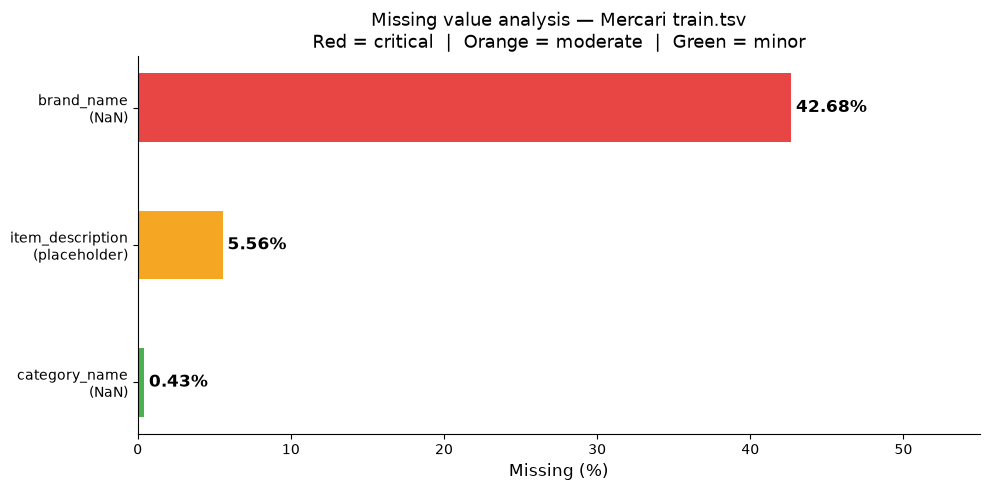

Saved to plots/missing_values.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

# Build the data to plot — only columns with any missingness
missing_data = {
    'brand_name\n(NaN)':              42.68,
    'item_description\n(placeholder)': 5.56,
    'category_name\n(NaN)':            0.43,
}

colors = ['#E84545', '#F5A623', '#4CAF50']
bars = ax.barh(list(missing_data.keys()), 
               list(missing_data.values()), 
               color=colors, 
               edgecolor='none', 
               height=0.5)

# Add percentage labels at the end of each bar
for bar, val in zip(bars, missing_data.values()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=12, fontweight='bold')

ax.set_xlabel('Missing (%)', fontsize=12)
ax.set_title('Missing value analysis — Mercari train.tsv\n'
             'Red = critical  |  Orange = moderate  |  Green = minor',
             fontsize=13)
ax.set_xlim(0, 55)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved to plots/missing_values.png")

# Price Distribution

In [14]:
print("=== Price statistics ===\n")
print(f"Count   : {df['price'].count():,}")
print(f"Min     : ${df['price'].min():.2f}")
print(f"25th %  : ${df['price'].quantile(0.25):.2f}")
print(f"Median  : ${df['price'].median():.2f}")
print(f"Mean    : ${df['price'].mean():.2f}")
print(f"75th %  : ${df['price'].quantile(0.75):.2f}")
print(f"95th %  : ${df['price'].quantile(0.95):.2f}")
print(f"99th %  : ${df['price'].quantile(0.99):.2f}")
print(f"Max     : ${df['price'].max():,.2f}")
print(f"\nSkewness : {df['price'].skew():.2f}")
print(f"\n$0 listings : {(df['price'] == 0).sum():,}")
print(f"<$3 listings: {(df['price'] < 3).sum():,}")

=== Price statistics ===

Count   : 1,482,535
Min     : $0.00
25th %  : $10.00
Median  : $17.00
Mean    : $26.74
75th %  : $29.00
95th %  : $75.00
99th %  : $170.00
Max     : $2,009.00

Skewness : 11.39

$0 listings : 874
<$3 listings: 874


- Skewness of `11.39` is extreme. For context — a perfectly symmetric distribution has skewness `0`, anything above `1` is considered highly skewed, and above `3` is severe. At `11.39`, this is one of the most skewed distributions encountered in practice. The cause is visible in the percentiles: `75%` of items cost under `$29`, yet the maximum is `$2,009`. A tiny fraction of expensive items are dragging the mean far above the median.

- Mean `($26.74)` is roughly `50%` higher than the median ($17.00). In a symmetric distribution these would be equal. The gap here is entirely caused by the long right tail of expensive items.

- `874` listings at exactly `$0`, and nothing between `$0` and `$3`. `$0` listings and `<$3` listings are both 874 — meaning there are zero listings priced at `$1` or `$2`. Every listing is either exactly `$0` or `$3` and above. This simplifies my cleaning: I will remove exactly those `874` rows and the minimum price becomes `$3`.

- `99%` of items are under `$170`, but the max is `$2,009`. That top `1%` spans an enormous range. This is the tail that creates the skew problem. All of this motivates the log transform.

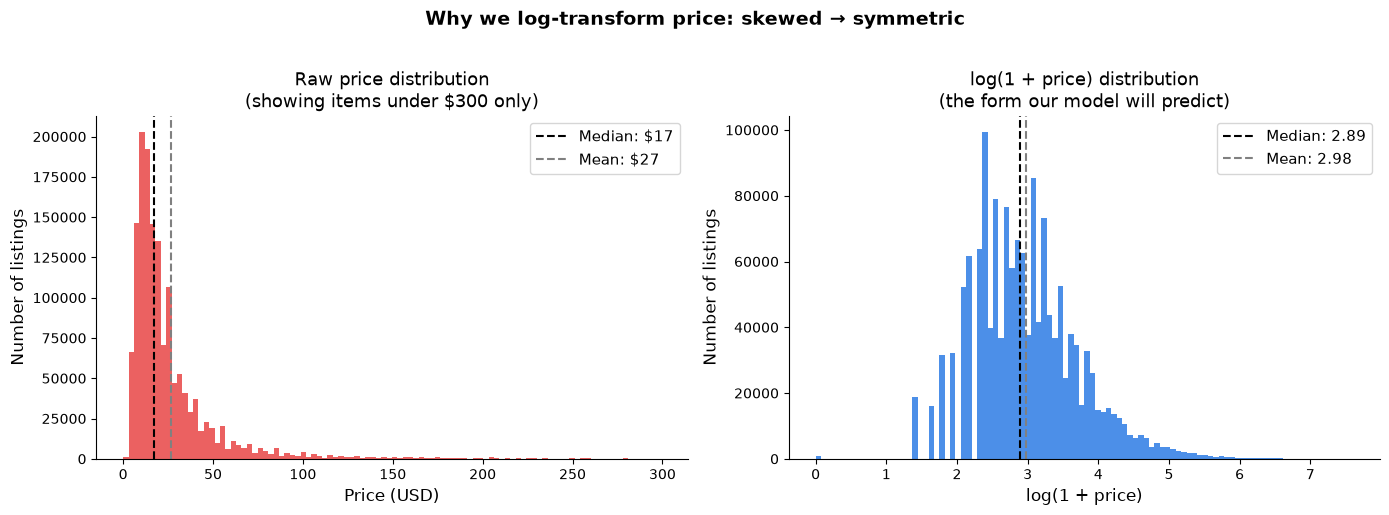

Raw price skewness      : 11.39
Log price skewness      : 0.66

Saved to plots/price_distribution.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: raw price (capped at $300 to show the bulk clearly) ---
prices_under_300 = df[df['price'] < 300]['price']
axes[0].hist(prices_under_300, bins=100, color='#E84545', edgecolor='none', alpha=0.85)
axes[0].axvline(df['price'].median(), color='black', linestyle='--', 
                linewidth=1.5, label=f"Median: ${df['price'].median():.0f}")
axes[0].axvline(df['price'].mean(), color='gray', linestyle='--', 
                linewidth=1.5, label=f"Mean: ${df['price'].mean():.0f}")
axes[0].set_title('Raw price distribution\n(showing items under $300 only)', fontsize=13)
axes[0].set_xlabel('Price (USD)', fontsize=12)
axes[0].set_ylabel('Number of listings', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Right plot: log(1 + price) ---
log_prices = np.log1p(df['price'])
axes[1].hist(log_prices, bins=100, color='#2C7BE5', edgecolor='none', alpha=0.85)
axes[1].axvline(log_prices.median(), color='black', linestyle='--', 
                linewidth=1.5, label=f"Median: {log_prices.median():.2f}")
axes[1].axvline(log_prices.mean(), color='gray', linestyle='--', 
                linewidth=1.5, label=f"Mean: {log_prices.mean():.2f}")
axes[1].set_title('log(1 + price) distribution\n(the form our model will predict)', fontsize=13)
axes[1].set_xlabel('log(1 + price)', fontsize=12)
axes[1].set_ylabel('Number of listings', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Why we log-transform price: skewed → symmetric', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Raw price skewness      : {df['price'].skew():.2f}")
print(f"Log price skewness      : {np.log1p(df['price']).skew():.2f}")
print(f"\nSaved to plots/price_distribution.png")

- From `11.39` to `0.66`. That single number summarizes why the log transform is so important — the distribution went from extremely skewed to nearly symmetric. It's not perfectly `0`, and it doesn't need to be. A skewness of `0.66` is well within the range that machine learning models handle comfortably.

- To make this concrete: before the transform, a `$2,009` item would create an enormous prediction error that would dominate training and cause the model to over-focus on expensive outliers. After the transform, `log(1 + 2009) = 7.61` — the expensive items still exist but they no longer dwarf everything else numerically.

# Feature–Price Relationships

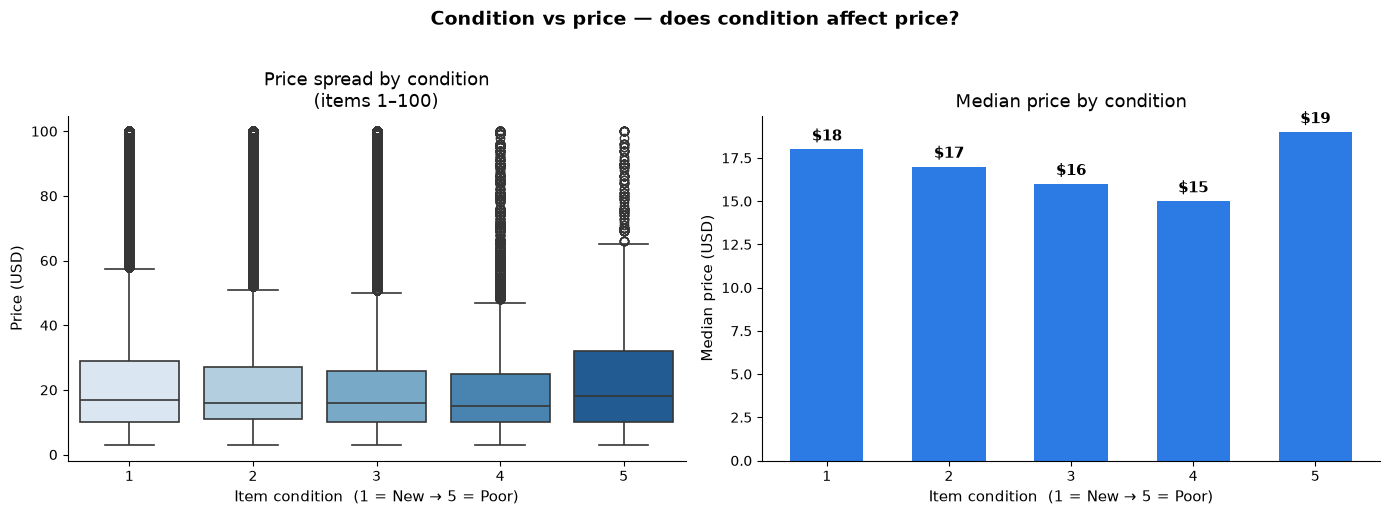

Median price by condition:
  Condition 1: $18.00
  Condition 2: $17.00
  Condition 3: $16.00
  Condition 4: $15.00
  Condition 5: $19.00


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: boxplot — shows the spread of prices at each condition level
# Cap at $100 so the boxes aren't crushed by outliers
sample = df[df['price'].between(1, 100)]
sns.boxplot(data=sample, x='item_condition_id', y='price',
            ax=axes[0], palette='Blues', linewidth=1.2)
axes[0].set_title('Price spread by condition\n(items $1–$100)', fontsize=13)
axes[0].set_xlabel('Item condition  (1 = New → 5 = Poor)', fontsize=11)
axes[0].set_ylabel('Price (USD)', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: median price per condition — easier to read the trend
median_by_condition = df.groupby('item_condition_id')['price'].median()
bars = axes[1].bar(median_by_condition.index, median_by_condition.values,
                   color='#2C7BE5', edgecolor='none', width=0.6)
for bar, val in zip(bars, median_by_condition.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'${val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Median price by condition', fontsize=13)
axes[1].set_xlabel('Item condition  (1 = New → 5 = Poor)', fontsize=11)
axes[1].set_ylabel('Median price (USD)', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Condition vs price — does condition affect price?', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/condition_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("Median price by condition:")
for cond, med in median_by_condition.items():
    print(f"  Condition {cond}: ${med:.2f}")

- There's a clear trend from condition `1` down to condition `4` — newer items cost more, which is exactly what I expected. But `condition 5` breaks the pattern with a median of `$19`, higher than conditions `2`, `3`, and `4`.

- Condition `5` has only `2,384` listings — the smallest group by far. When a sample is this small, unusual patterns emerge. More importantly, if we think about what kind of seller lists something in "Poor" condition: usually someone with a valuable item (electronics, collectibles, branded goods) who is being unusually honest. A broken iPhone or a worn vintage jacket might still command a decent price. Generic cheap items in poor condition simply don't get listed — they go in the bin. So the condition `5` median is high not because poor condition raises price, but because of what types of items get listed there.

- The overall differences are also small — `$15` to `$19`. Condition alone is a weak predictor. It will help the model at the margins, but it's not going to be the feature that drives accuracy. Brand and category will matter far more.

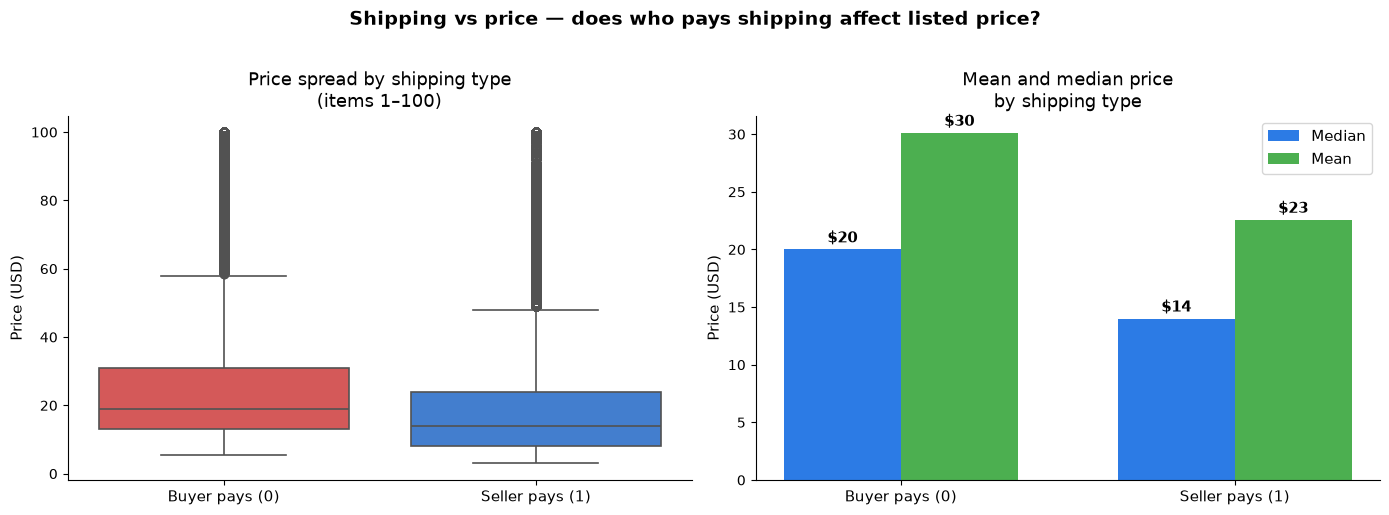

Price statistics by shipping type:
           mean  median
shipping               
0         30.11    20.0
1         22.57    14.0


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: boxplot
sample = df[df['price'].between(1, 100)]
sns.boxplot(data=sample, x='shipping', y='price',
            ax=axes[0], palette=['#E84545', '#2C7BE5'], linewidth=1.2)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Buyer pays (0)', 'Seller pays (1)'], fontsize=11)
axes[0].set_title('Price spread by shipping type\n(items $1–$100)', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Price (USD)', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: mean and median side by side
stats = df.groupby('shipping')['price'].agg(['mean', 'median'])
x = np.arange(2)
width = 0.35
bars1 = axes[1].bar(x - width/2, stats['median'], width, 
                     label='Median', color='#2C7BE5', edgecolor='none')
bars2 = axes[1].bar(x + width/2, stats['mean'], width, 
                     label='Mean', color='#4CAF50', edgecolor='none')
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'${bar.get_height():.0f}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'${bar.get_height():.0f}', ha='center', va='bottom', 
                 fontsize=11, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Buyer pays (0)', 'Seller pays (1)'], fontsize=11)
axes[1].set_title('Mean and median price\nby shipping type', fontsize=13)
axes[1].set_ylabel('Price (USD)', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Shipping vs price — does who pays shipping affect listed price?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/shipping_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("Price statistics by shipping type:")
print(stats.round(2))

- This is the opposite of what most people expect at first glance.

- When the buyer pays shipping (0), the median listed price is `$20`. When the seller pays shipping (1), the median is only `$14`. I expected seller-paid shipping to have higher listed prices — because sellers "bake in" the shipping cost. But the reality is different.

- What's actually happening: Sellers of cheaper items are more likely to offer free shipping to stay competitive. A `$10` item with `$5` shipping feels expensive to a buyer, so sellers absorb that cost. Sellers of slightly more expensive items don't need that incentive — buyers expect to pay shipping on a `$25+` purchase. The result: seller-paid shipping correlates with cheaper items, not more expensive ones.

- This means shipping isn't just a logistics flag — it's a price signal. The model will learn that shipping=1 is associated with lower-priced listings. Useful feature confirmed.

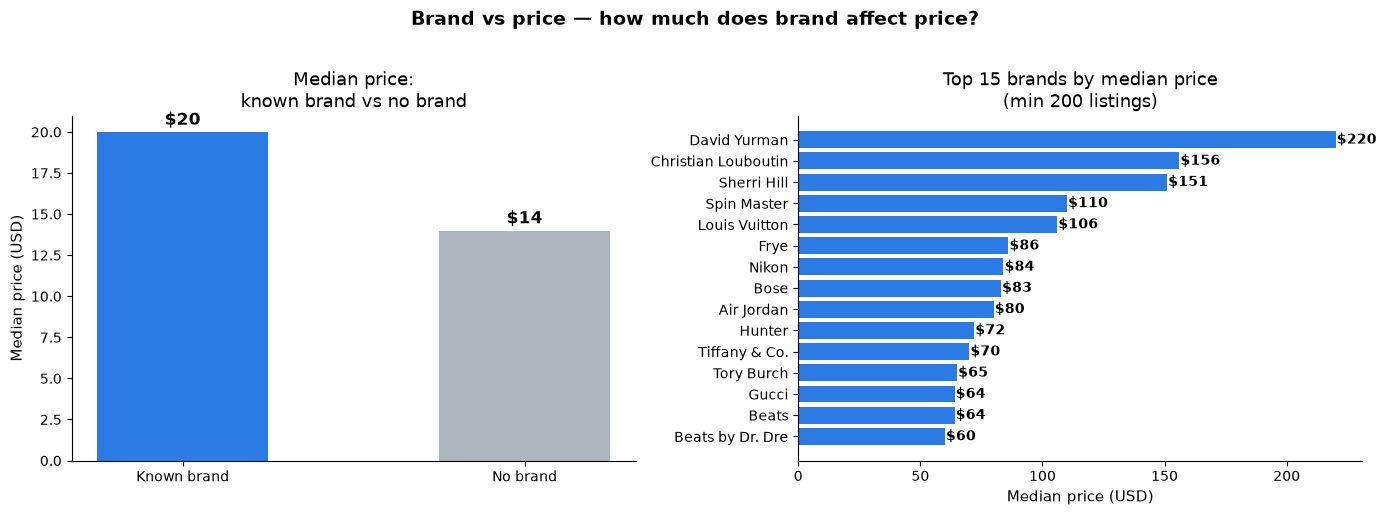

Known brand vs no brand — median price:
Known brand    20.0
No brand       14.0
Name: median, dtype: float64

Price premium of having a known brand: 1.4x

Top 10 brands by median price (min 200 listings):
brand_name
Hunter                  72.0
Air Jordan              80.0
Bose                    83.0
Nikon                   84.0
Frye                    86.0
Louis Vuitton          106.0
Spin Master            110.0
Sherri Hill            151.0
Christian Louboutin    156.0
David Yurman           220.0
Name: median, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: known brand vs no brand
brand_stats = df.groupby(df['brand_name'].isna())['price'].agg(['median', 'mean'])
brand_stats.index = ['Known brand', 'No brand']

bars = axes[0].bar(brand_stats.index, brand_stats['median'],
                   color=['#2C7BE5', '#adb5bd'], edgecolor='none', width=0.5)
for bar, val in zip(bars, brand_stats['median']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'${val:.0f}', ha='center', va='bottom', 
                 fontsize=12, fontweight='bold')
axes[0].set_title('Median price:\nknown brand vs no brand', fontsize=13)
axes[0].set_ylabel('Median price (USD)', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: top 15 brands by median price (min 200 listings for reliability)
top_brands = (df.groupby('brand_name')['price']
                .agg(['median', 'count'])
                .query('count >= 200')
                .sort_values('median', ascending=True)
                .tail(15))

axes[1].barh(top_brands.index, top_brands['median'],
             color='#2C7BE5', edgecolor='none')
for i, val in enumerate(top_brands['median']):
    axes[1].text(val + 0.5, i, f'${val:.0f}', 
                 va='center', fontsize=10, fontweight='bold')
axes[1].set_title('Top 15 brands by median price\n(min 200 listings)', fontsize=13)
axes[1].set_xlabel('Median price (USD)', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Brand vs price — how much does brand affect price?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/brand_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("Known brand vs no brand — median price:")
print(brand_stats['median'].round(2))
print(f"\nPrice premium of having a known brand: "
      f"{brand_stats['median']['Known brand'] / brand_stats['median']['No brand']:.1f}x")

print(f"\nTop 10 brands by median price (min 200 listings):")
print(top_brands['median'].tail(10).round(2))

- A `1.4x` premium on average, but that average hides an enormous range. The top 10 tells the real story — `David Yurman` at `$220` median vs the overall dataset median of `$17`. That's nearly a `13x` difference driven purely by brand identity. `Louis Vuitton` at `$106`, `Christian Louboutin` at `$156` — these are luxury goods that command prices an order of magnitude above typical listings.

- The `1.4x` overall average is modest because `"known brand"` includes everything from `Old Navy` and `Forever 21` at the low end to these luxury names at the top. The specific brand identity matters enormously, not just whether a brand exists. This directly motivates two separate features we'll engineer later — a `binary brand_known flag` to capture the general premium, and a `label-encoded brand_name column` to capture the specific brand's price level.

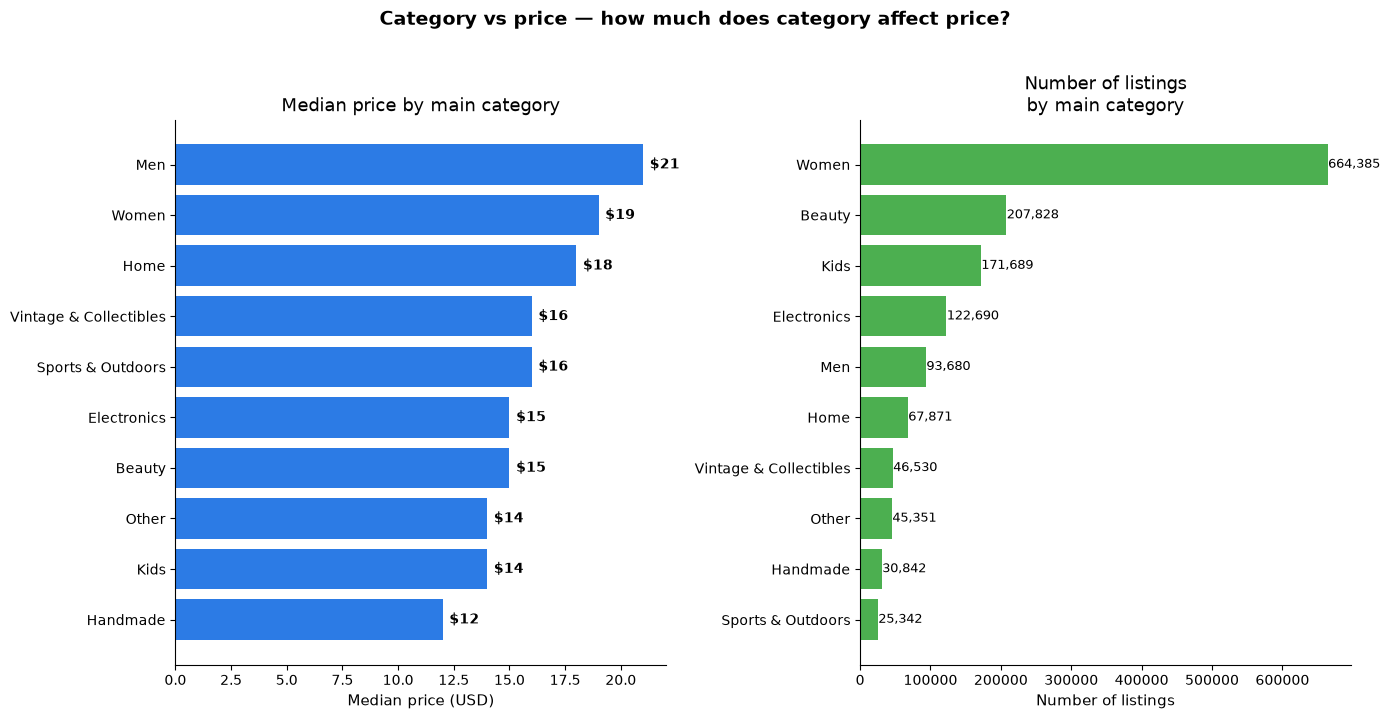

Median price by main category (sorted low to high):
  Handmade                            $12  (30,842.0 listings)
  Kids                                $14  (171,689.0 listings)
  Other                               $14  (45,351.0 listings)
  Beauty                              $15  (207,828.0 listings)
  Electronics                         $15  (122,690.0 listings)
  Sports & Outdoors                   $16  (25,342.0 listings)
  Vintage & Collectibles              $16  (46,530.0 listings)
  Home                                $18  (67,871.0 listings)
  Women                               $19  (664,385.0 listings)
  Men                                 $21  (93,680.0 listings)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Compute median price per top-level category (cat_1)
# We extract it temporarily here just for EDA — the full split happens in Step 9
df['cat_1_temp'] = df['category_name'].str.split('/').str[0]

cat_stats = (df.groupby('cat_1_temp')['price']
               .agg(['median', 'count'])
               .query('count >= 100')
               .sort_values('median', ascending=True))

# Left: median price by main category
axes[0].barh(cat_stats.index, cat_stats['median'],
             color='#2C7BE5', edgecolor='none')
for i, val in enumerate(cat_stats['median']):
    axes[0].text(val + 0.3, i, f'${val:.0f}',
                 va='center', fontsize=10, fontweight='bold')
axes[0].set_title('Median price by main category', fontsize=13)
axes[0].set_xlabel('Median price (USD)', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: number of listings per main category
cat_counts = cat_stats['count'].sort_values(ascending=True)
axes[1].barh(cat_counts.index, cat_counts.values,
             color='#4CAF50', edgecolor='none')
for i, val in enumerate(cat_counts.values):
    axes[1].text(val + 500, i, f'{val:,}',
                 va='center', fontsize=9)
axes[1].set_title('Number of listings\nby main category', fontsize=13)
axes[1].set_xlabel('Number of listings', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Category vs price — how much does category affect price?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/category_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

print("Median price by main category (sorted low to high):")
for cat, row in cat_stats.iterrows():
    print(f"  {cat:<35} ${row['median']:.0f}  ({row['count']:,} listings)")

# Clean up temporary column
df.drop(columns=['cat_1_temp'], inplace=True)

- The range from `$12` to `$21` across main categories is surprisingly narrow. At first glance I expected `Electronics` to be the most expensive category — but it sits at `$15`, same as `Beauty`. The reason is that most Electronics listings aren't laptops and phones — they're phone cases, cables, and accessories. The expensive items exist but are vastly outnumbered by cheap accessories. This is exactly why splitting categories into three levels matters. The top-level category alone is too coarse to carry strong price signal. `"Electronics/Computers & Tablets/Laptops & Netbooks"` tells a very different price story than `"Electronics/Cell Phones & Accessories/Cases, Covers & Skins"`, but at `level 1` they both just say `"Electronics"`.

- `Women` dominates at `664,385` listings — roughly `50%` of the entire dataset. The model will be trained mostly on Women's items. That's not a problem, it's just the reality of this marketplace.

# Data Cleaning

In [20]:
before = len(df)

df = df[df['price'] > 0].reset_index(drop=True)

after = len(df)
print(f"Rows before : {before:,}")
print(f"Rows removed: {before - after:,}")
print(f"Rows after  : {after:,}")
print(f"\nNew price minimum: ${df['price'].min():.2f}")

Rows before : 1,482,535
Rows removed: 874
Rows after  : 1,481,661

New price minimum: $3.00


- I will fill brand_name with `"unknown"`, I am telling the model that `"unknown brand"` is a real category with its own price patterns. The model can learn that unknown-brand items have a typical price range. If I filled with an empty string or `0`, the model would either crash or misinterpret the value.

- For category_name I use "missing/missing/missing" specifically because later I'll split on / to create three columns. By using this placeholder, all three resulting columns get "missing" consistently rather than one getting a value and two getting blanks.

- For item_description I treat both the real `NaNs` and the `"No description yet"` placeholders identically — both mean the seller provided no useful description.

In [21]:
# --- brand_name ---
# 42.68% missing — fill with "unknown" so the model treats
# no-brand items as their own distinct group
df['brand_name'] = df['brand_name'].fillna('unknown')

# --- category_name ---
# 0.43% missing — use the 3-part placeholder so when we split
# on '/' in Step 9, all three levels become "missing" consistently
df['category_name'] = df['category_name'].fillna('missing/missing/missing')

# --- item_description ---
# Fill both the 6 real NaNs AND the 82,489 "No description yet" 
# placeholders with the same replacement string
df['item_description'] = df['item_description'].fillna('no description')
df['item_description'] = df['item_description'].replace(
    'No description yet', 'no description'
)

# Verify
print("Missing values after cleaning:")
print(f"  brand_name       : {df['brand_name'].isna().sum()}")
print(f"  category_name    : {df['category_name'].isna().sum()}")
print(f"  item_description : {df['item_description'].isna().sum()}")
print(f"\n'No description yet' remaining: "
      f"{(df['item_description'] == 'No description yet').sum()}")
print(f"'no description' count        : "
      f"{(df['item_description'] == 'no description').sum():,}")
print(f"\nDataset shape: {df.shape}")

Missing values after cleaning:
  brand_name       : 0
  category_name    : 0
  item_description : 0

'No description yet' remaining: 0
'no description' count        : 82,434

Dataset shape: (1481661, 8)


# Log-Transform the Target

In [22]:
df['log_price'] = np.log1p(df['price'])

print("log_price column created.")
print(f"\nOriginal price  → log_price examples:")
print(f"  $3.00   → {np.log1p(3):.4f}")
print(f"  $10.00  → {np.log1p(10):.4f}")
print(f"  $17.00  → {np.log1p(17):.4f}  (median)")
print(f"  $50.00  → {np.log1p(50):.4f}")
print(f"  $100.00 → {np.log1p(100):.4f}")
print(f"  $500.00 → {np.log1p(500):.4f}")
print(f"  $2009.00→ {np.log1p(2009):.4f}")

print(f"\nlog_price stats:")
print(df['log_price'].describe().round(4))
print(f"\nDataset shape: {df.shape}")

log_price column created.

Original price  → log_price examples:
  $3.00   → 1.3863
  $10.00  → 2.3979
  $17.00  → 2.8904  (median)
  $50.00  → 3.9318
  $100.00 → 4.6151
  $500.00 → 6.2166
  $2009.00→ 7.6059

log_price stats:
count    1.481661e+06
mean     2.980800e+00
std      7.459000e-01
min      1.386300e+00
25%      2.397900e+00
50%      2.890400e+00
75%      3.401200e+00
max      7.605900e+00
Name: log_price, dtype: float64

Dataset shape: (1481661, 9)


- Notice how the gap between values compresses as prices get larger. The difference between `$3` and `$10` is `$7` in raw terms but only `0.82` in log terms. The difference between `$500` and `$2,009` is `$1,509` in raw terms but only `1.39` in log terms. The log scale treats proportional differences equally — being `2×` more expensive always adds the same amount in log space regardless of whether we're talking about `$10` vs `$20` or `$500` vs `$1,000`. This is exactly what RMSLE measures.

- The std of `0.7459` tells us that in log space, prices are tightly clustered — most listings fall within a narrow band, which is ideal for a model to learn from. The full range is `1.39` to `7.61`, a span of just `6.2` units in log space compared to `$3` to `$2,009` in dollar space.

# Text & Category Cleaning

- I do minimal text cleaning on `name` and `item_description`. Then I split the `category_name` hierarchy into three separate columns.

- I don't do the typical remove punctuation, strip numbers, apply stemming, and remove stop words. For TF-IDF specifically, most of that is counterproductive. The `TfidfVectorizer` I'll use later handles `lowercasing` and `tokenization` internally. Its `IDF` component automatically downweights words like `"the"` and `"and"` that appear everywhere — so explicit stop word removal is redundant. Stemming adds code complexity for marginal gain. The one thing I do handle explicitly is `whitespace normalisation`, because leading/trailing spaces and double spaces can cause the same word to be treated as different tokens.

- I deliberately keep `[rm]` tokens. Mercari inserted these where sellers wrote prices in their descriptions. A listing that says "retail for `[rm]`" is signalling something — the seller knew a reference price existed. Removing `[rm]` would discard that signal.

In [23]:
import re

def clean_text(text):
    """
    Minimal cleaning for TF-IDF text columns.
    - Lowercase
    - Normalize whitespace
    - Keep [rm] tokens intact
    """
    if not isinstance(text, str):
        return 'no description'
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['name'] = df['name'].apply(clean_text)
df['item_description'] = df['item_description'].apply(clean_text)

# Verify
print("Text cleaning complete.")
print(f"\nSample cleaned names:")
for name in df['name'].sample(5, random_state=42).values:
    print(f"  '{name}'")
print(f"\nSample cleaned descriptions (first 100 chars):")
for desc in df['item_description'].sample(5, random_state=42).values:
    print(f"  '{desc[:100]}'")

Text cleaning complete.

Sample cleaned names:
  'mickey mouse crop top'
  'converse shoreline wm's sneaker sz 9'
  'shellshell bundle'
  'wallflower plugins'
  'new nike pros hot pink size m'

Sample cleaned descriptions (first 100 chars):
  'white crop top. mickey mouse design on the front. bought from a retail store so the disney tag was c'
  'chuck taylor's shoreline women's sneaker size 9 no low balling offer please. thank you! brand new re'
  '3 leotards as pictured'
  'five of them'
  'bought for my daughter and they are too small so she's never worn them.'


In [24]:
# Split "Women/Tops & Blouses/T-Shirts" into three columns
# n=2 means split at most twice → always produces exactly 3 parts
splits = df['category_name'].str.split('/', n=2, expand=True)

df['cat_1'] = splits[0].str.lower().str.strip()  # main section
df['cat_2'] = splits[1].str.lower().str.strip()  # subsection
df['cat_3'] = splits[2].str.lower().str.strip()  # specific type

# The placeholder "missing/missing/missing" becomes
# cat_1="missing", cat_2="missing", cat_3="missing" — exactly what we want

print("Category split complete.")
print(f"\nUnique values per level:")
print(f"  cat_1 : {df['cat_1'].nunique():,}")
print(f"  cat_2 : {df['cat_2'].nunique():,}")
print(f"  cat_3 : {df['cat_3'].nunique():,}")

print(f"\nSample — original vs split:")
sample_cats = df[['category_name', 'cat_1', 'cat_2', 'cat_3']].sample(8, random_state=1)
for _, row in sample_cats.iterrows():
    print(f"  '{row['category_name']}'")
    print(f"    → cat_1='{row['cat_1']}'  cat_2='{row['cat_2']}'  cat_3='{row['cat_3']}'")
    print()

print(f"Dataset shape: {df.shape}")

Category split complete.

Unique values per level:
  cat_1 : 11
  cat_2 : 114
  cat_3 : 871

Sample — original vs split:
  'Women/Athletic Apparel/Pants, Tights, Leggings'
    → cat_1='women'  cat_2='athletic apparel'  cat_3='pants, tights, leggings'

  'Home/Kitchen & Dining/Dining & Entertaining'
    → cat_1='home'  cat_2='kitchen & dining'  cat_3='dining & entertaining'

  'Other/Daily & Travel items/Personal Care'
    → cat_1='other'  cat_2='daily & travel items'  cat_3='personal care'

  'Other/Daily & Travel items/Personal Care'
    → cat_1='other'  cat_2='daily & travel items'  cat_3='personal care'

  'Women/Women's Accessories/Sunglasses'
    → cat_1='women'  cat_2='women's accessories'  cat_3='sunglasses'

  'Kids/Girls 2T-5T/Shoes'
    → cat_1='kids'  cat_2='girls 2t-5t'  cat_3='shoes'

  'Men/Shoes/Athletic'
    → cat_1='men'  cat_2='shoes'  cat_3='athletic'

  'Men/Men's Accessories/Wallets'
    → cat_1='men'  cat_2='men's accessories'  cat_3='wallets'

Dataset shape: (148

- `cat_1` captures `department-level` price patterns, `cat_2` captures `subcategory` patterns, and `cat_3` captures the `most specific type`. The model learns each independently and combines them.

# Feature Engineering

- I am creating new numeric columns the model can actually learn from. Raw text, categories, and brand names can't go directly into any model — they need to be converted to numbers first. I also create simple numeric features that capture information the model couldn't extract on its own.

- I saw that `brand` presence affects `price` — so I am creating `brand_known.` I saw that `name` and `descriptions` vary enormously in `length` and `quality` — so I am creating `length` and `word` count features. I saw that `category` and `brand identity` specifically matter — so I am encoding them.

- I am creating two types of features here:
Type 1 — `Numeric features`: Simple numbers the model can use directly. Fast to compute, easy to explain.
Type 2 — `TF-IDF features`: Sparse high-dimensional vectors from text. Slower to compute, much more powerful for text data.

- I am creating both `word count` and `character length` because they're correlated but not identical. `"$$$"` has `3` characters but `1` word. `"a b c"` has `5` characters but `3` words. Short choppy descriptions (3 words) feel different from long single-word product codes (30 characters). Both tell the model something slightly different, so I keep both.

- I also created `binary flags` instead of just relying on the encoded columns because label-encoded brand_name will encode "unknown" as some arbitrary integer — say `4,201`. The model has no way to know that `4,201` specifically means `"no brand."` The binary `brand_known` column makes this completely explicit — `0` means `no brand`, `1` means there `is one`.

In [25]:
# --- Length features ---
# Capture how much text the seller provided
# Motivated by Step 6.4: longer descriptions correlate with higher prices
df['name_len']        = df['name'].str.len()
df['desc_len']        = df['item_description'].str.len()
df['name_word_count'] = df['name'].str.split().str.len()
df['desc_word_count'] = df['item_description'].str.split().str.len()

# --- Binary flags ---
# has_description: did the seller write a real description?
# Motivated by Step 3.6: 82,495 listings have no real description
df['has_description'] = (df['item_description'] != 'no description').astype(int)

# brand_known: does this listing have a known brand?
# Motivated by Step 6.3: known brands command 1.4x higher median price
df['brand_known'] = (df['brand_name'] != 'unknown').astype(int)

# Verify
print("Length and binary features created.")
print(f"\nNew columns: name_len, desc_len, name_word_count, "
      f"desc_word_count, has_description, brand_known")
print(f"\nSummary statistics:")
new_cols = ['name_len', 'desc_len', 'name_word_count', 
            'desc_word_count', 'has_description', 'brand_known']
print(df[new_cols].describe().round(2))

print(f"\nhas_description=1 (has real description): "
      f"{df['has_description'].sum():,} ({df['has_description'].mean()*100:.1f}%)")
print(f"brand_known=1 (known brand)            : "
      f"{df['brand_known'].sum():,} ({df['brand_known'].mean()*100:.1f}%)")

Length and binary features created.

New columns: name_len, desc_len, name_word_count, desc_word_count, has_description, brand_known

Summary statistics:
         name_len    desc_len  name_word_count  desc_word_count  \
count  1481661.00  1481661.00       1481661.00       1481661.00   
mean        25.79      145.46             4.40            25.63   
std          9.16      174.53             1.65            30.44   
min          1.00        1.00             1.00             1.00   
25%         19.00       40.00             3.00             7.00   
50%         26.00       86.00             4.00            15.00   
75%         34.00      174.00             6.00            31.00   
max         43.00     1046.00            17.00           245.00   

       has_description  brand_known  
count       1481661.00   1481661.00  
mean              0.94         0.57  
std               0.23         0.49  
min               0.00         0.00  
25%               1.00         0.00  
50%           

- `94.4%` have real descriptions and `57.3%` have a known brand. Both features have enough variation to be useful.

- The description length statistics are interesting — mean `145` characters but max `1,046`, with a std of `174`. That's a wide spread. Some sellers write essays, most write a sentence or two. The model will learn that the length itself is a signal.

- I am using `label encoding` and not `one-hot encoding` because `one-hot encoding` creates one new binary column per unique value. brand_name has `4,809` unique values — that would create `4,809` extra columns just for brand, most with very few `1s`. This is wasteful and slow. Label encoding keeps everything in a single column. Tree-based models like `LightGBM` handle label-encoded categoricals perfectly because they find splits by comparing values, not by assuming any ordering. Linear models are slightly less comfortable with label encoding, but since these features will be a small part of a much larger feature matrix (dominated by TF-IDF), the impact is minimal.

In [26]:
from sklearn.preprocessing import LabelEncoder

# Columns to encode
cat_cols = ['cat_1', 'cat_2', 'cat_3', 'brand_name']

# Store encoders in case we need them later (Phase III)
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"  '{col}' → {df[col].nunique():,} unique values "
          f"→ encoded to integers 0–{df[col].nunique()-1}")

print(f"\nSample — brand_name encoding:")
sample = df[['brand_name', 'brand_name_encoded']].drop_duplicates().sample(8, random_state=1)
for _, row in sample.iterrows():
    print(f"  '{row['brand_name']}' → {row['brand_name_encoded']}")

print(f"\nDataset shape: {df.shape}")

  'cat_1' → 11 unique values → encoded to integers 0–10
  'cat_2' → 114 unique values → encoded to integers 0–113
  'cat_3' → 871 unique values → encoded to integers 0–870
  'brand_name' → 4,808 unique values → encoded to integers 0–4807

Sample — brand_name encoding:
  'Southpole' → 3986
  'Lyle & Scott' → 2633
  'Trouve' → 4369
  'Nudie Jeans' → 3101
  'Bitten' → 583
  'FootJoy' → 1607
  'Brave Soul' → 682
  'David Kahn' → 1195

Dataset shape: (1481661, 22)


# TF-IDF Features

- The `name` and `item_description` columns contain the richest information in the dataset — but it's locked inside raw text. I am using TF-IDF conversion to convert text into numbers.

- TF (Term Frequency): how often this word appears in this specific listing
- IDF (Inverse Document Frequency): a penalty for words that appear in many listings — common words get a low score, rare words get a high score
- Final score = TF × IDF: high only for words that are frequent in this listing AND rare across all listings The result is a matrix where each row is a listing and each column is a word. Most values are 0 (the word doesn't appear in that listing) — this is called a sparse matrix and scipy handles it very efficiently.

- I will FIT here but TRANSFORM later because fitting means learning the vocabulary and IDF weights from the data. Transforming means converting text into the numeric matrix. I fit now and transform later when building the feature matrix. This keeps the phases cleanly separated and means I can save the fitted vectorizer and reuse it later for the API.

- `ngram_range=(1, 2)`: Single words like `"jordan"` or `"apple"` are useful. But two-word phrases like `"air jordan"` or `"apple watch"` are far more specific. `(1, 2)` means we capture both. We stop at `2` because three-word phrases appear too rarely to be reliable.

- `min_df=2`: Words appearing in only one listing are almost certainly typos or unique product codes. They'll never match another listing so they add no predictive value — only noise and memory usage.

- `sublinear_tf=True`: If someone writes `"new"` `10` times in a description, the word isn't `10` times more informative than writing it once. Taking `log(tf)` compresses this — the `10th` repetition adds much less than the first.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_name = TfidfVectorizer(
    max_features=50_000,   # keep top 50,000 most informative terms
    ngram_range=(1, 2),    # single words AND two-word phrases
    min_df=2,              # ignore words appearing in fewer than 2 listings
    sublinear_tf=True,     # apply log(tf) instead of raw tf — reduces effect of repetition
    strip_accents='unicode',
    analyzer='word'
)

tfidf_name.fit(df['name'])

print(f"TF-IDF fitted on product names.")
print(f"Vocabulary size: {len(tfidf_name.vocabulary_):,} terms")
print(f"\nSample terms learned (first 30):")
sample_terms = list(tfidf_name.vocabulary_.keys())[:30]
print(f"  {sample_terms}")

print(f"\nTop IDF scores (rarest, most specific words):")
idf_scores = dict(zip(tfidf_name.get_feature_names_out(), tfidf_name.idf_))
top_idf = sorted(idf_scores.items(), key=lambda x: x[1], reverse=True)[:10]
for term, score in top_idf:
    print(f"  '{term}': {score:.4f}")

print(f"\nLowest IDF scores (most common, least informative words):")
bottom_idf = sorted(idf_scores.items(), key=lambda x: x[1])[:10]
for term, score in bottom_idf:
    print(f"  '{term}': {score:.4f}")

TF-IDF fitted on product names.
Vocabulary size: 50,000 terms

Sample terms learned (first 30):
  ['mlb', 'cincinnati', 'reds', 'shirt', 'size', 'xl', 'cincinnati reds', 'shirt size', 'size xl', 'razer', 'blackwidow', 'chroma', 'keyboard', 'razer blackwidow', 'ava', 'viv', 'blouse', 'ava viv', 'leather', 'horse', 'statues', '24k', 'gold', 'plated', 'rose', '24k gold', 'gold plated', 'bundled', 'items', 'requested']

Top IDF scores (rarest, most specific words):
  'bom': 13.0115
  'bora': 12.9061
  'zhu': 12.8108
  'hold hold': 12.5696
  'it is': 12.5006
  '100 assorted': 12.4361
  '100 latex': 12.4361
  '18 24mo': 12.4361
  '21 green': 12.4361
  '21 one': 12.4361

Lowest IDF scores (most common, least informative words):
  'pink': 3.8781
  'bundle': 3.9475
  'new': 3.9621
  'size': 4.0101
  'lularoe': 4.1513
  'for': 4.2171
  'black': 4.2723
  'nike': 4.4648
  'and': 4.4765
  'vs': 4.5100


- Lowest IDF = most common words: `"pink"` has the absolute lowest IDF score in the entire `50,000`-term vocabulary. It appears in so many listings — both as the `PINK brand` and as a `color descriptor` across women's clothing — that it barely distinguishes one listing from another. `"new"`, `"size"`, `"bundle"` are similarly ubiquitous. These won't carry much weight in predictions.

- Highest IDF = rarest words: `"bom"`, `"bora"`, `"zhu"` appear in almost no listings. When they do appear, they signal something very specific. The bigrams like `"100 assorted"` or `"18 24mo"` are extremely niche — a listing containing `"18 24mo"` is almost certainly children's clothing sized `18-24 months`, which is a very specific price context.

- The bigrams are working perfectly: `"cincinnati reds"`, `"razer blackwidow"`, `"24k gold"` — these two-word phrases carry far more meaning than their individual words. `"razer"` alone could mean many things; `"razer blackwidow"` means exactly one product.

- I am using `min_df=3` instead of `min_df=2` for descriptions because they are longer than `names`, which means rare words appear more often just by chance — a seller might mention a niche brand once in passing that never appears in any other listing. Being slightly stricter filters more of this noise out while keeping genuinely informative terms.

In [28]:
tfidf_desc = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=3,              # slightly stricter than name — descriptions are longer
    sublinear_tf=True,     # so rare words in descriptions are more likely noise
    strip_accents='unicode',
    analyzer='word'
)

tfidf_desc.fit(df['item_description'])

print(f"TF-IDF fitted on item descriptions.")
print(f"Vocabulary size: {len(tfidf_desc.vocabulary_):,} terms")

print(f"\nLowest IDF scores (most common words in descriptions):")
idf_scores_desc = dict(zip(tfidf_desc.get_feature_names_out(), tfidf_desc.idf_))
bottom_idf_desc = sorted(idf_scores_desc.items(), key=lambda x: x[1])[:10]
for term, score in bottom_idf_desc:
    print(f"  '{term}': {score:.4f}")

print(f"\nTop IDF scores (rarest terms in descriptions):")
top_idf_desc = sorted(idf_scores_desc.items(), key=lambda x: x[1], reverse=True)[:10]
for term, score in top_idf_desc:
    print(f"  '{term}': {score:.4f}")

TF-IDF fitted on item descriptions.
Vocabulary size: 50,000 terms

Lowest IDF scores (most common words in descriptions):
  'and': 2.0906
  'new': 2.1711
  'size': 2.3269
  'in': 2.3515
  'for': 2.4286
  'with': 2.4340
  'the': 2.4892
  'is': 2.6252
  'to': 2.6283
  'no': 2.6768

Top IDF scores (rarest terms in descriptions):
  'ijust': 12.2642
  'spin while': 12.1176
  'sheet choose': 11.8765
  'setp': 11.8075
  'rm pcs': 11.6823
  'movies rm': 11.6252
  'teal flower': 11.5978
  'ʏᴏᴜ': 11.5978
  'matte for': 11.4710
  'rm samsung': 11.4710


- Looking at the lowest IDF scores — pure English stopwords: `"and"`, `"the"`, `"in"`, `"for"`, `"with"`. `Names` barely contained these because product names are terse and keyword-focused. Descriptions are written in natural sentences, so these common words flood in. TF-IDF handles this automatically — their low IDF scores mean they'll contribute almost nothing to predictions even though they appear constantly.

- The `[rm]` tokens are showing up in the rarest phrases — `"rm pcs"`, `"movies rm"`, `"rm samsung"`. This confirms my decision to keep them. They appear in specific contexts the model can learn from: `"rm samsung"` is almost certainly "`[rm]` Samsung" — a listing that mentioned a Samsung product price, which signals a specific type of electronics listing.
`"ʏᴏᴜ"` in small-cap Unicode is someone being stylistic in their description — real user-generated data at its finest. It made it through `min_df=3` meaning at least 3 sellers used this exact character. The model will quietly learn it's associated with whatever type of listing uses decorative Unicode.

In [29]:
import joblib

joblib.dump(tfidf_name, 'models/tfidf_name.pkl')
joblib.dump(tfidf_desc, 'models/tfidf_desc.pkl')
joblib.dump(encoders,   'models/label_encoders.pkl')

print("Saved fitted objects to models/:")
print("  models/tfidf_name.pkl       — TF-IDF vectorizer for product names")
print("  models/tfidf_desc.pkl       — TF-IDF vectorizer for descriptions")
print("  models/label_encoders.pkl   — label encoders for cat_1/cat_2/cat_3/brand_name")
print()
print("Why save these now:")
print("  Phase II loads them to transform text into the feature matrix")
print("  Phase III loads them to process new listings sent to the API")
print("  Re-fitting in Phase III would produce a different vocabulary mapping")
print("  — the same word would get a different column index — breaking predictions")

Saved fitted objects to models/:
  models/tfidf_name.pkl       — TF-IDF vectorizer for product names
  models/tfidf_desc.pkl       — TF-IDF vectorizer for descriptions
  models/label_encoders.pkl   — label encoders for cat_1/cat_2/cat_3/brand_name

Why save these now:
  Phase II loads them to transform text into the feature matrix
  Phase III loads them to process new listings sent to the API
  Re-fitting in Phase III would produce a different vocabulary mapping
  — the same word would get a different column index — breaking predictions


# Feature Selection

- I am evaluating which of our `12` numeric features actually carry useful signal. I use two methods — `Pearson correlation` and `LightGBM` importance — because correlation only measures linear relationships while `LightGBM` can detect non-linear ones too. Getting two independent opinions is more reliable than trusting just one.

- The `TF-IDF` features (50,000 from names + 50,000 from descriptions = 100,000 total) are not evaluated individually here — there are too many to analyse one by one, and individual TF-IDF terms are rarely useful in isolation anyway. We include all of them by default.

In [30]:
numeric_features = [
    'item_condition_id', 'shipping',
    'cat_1_encoded', 'cat_2_encoded', 'cat_3_encoded',
    'brand_name_encoded',
    'name_len', 'desc_len',
    'name_word_count', 'desc_word_count',
    'has_description', 'brand_known'
]

correlations = (
    df[numeric_features + ['log_price']]
    .corr()['log_price']
    .drop('log_price')
    .sort_values(key=abs, ascending=False)
)

print("Pearson correlation with log_price (sorted by absolute strength):")
print("=" * 60)
for feat, corr in correlations.items():
    bar       = '█' * int(abs(corr) * 60)
    direction = '+' if corr >= 0 else '-'
    strength  = 'strong' if abs(corr) > 0.15 else 'moderate' if abs(corr) > 0.05 else 'weak'
    print(f"  {feat:<25} {direction}{abs(corr):.4f}  {bar}  ({strength})")

Pearson correlation with log_price (sorted by absolute strength):
  shipping                  -0.2313  █████████████  (strong)
  brand_known               +0.2059  ████████████  (strong)
  brand_name_encoded        -0.1426  ████████  (moderate)
  cat_1_encoded             +0.1243  ███████  (moderate)
  name_word_count           +0.0533  ███  (moderate)
  has_description           +0.0471  ██  (weak)
  name_len                  +0.0468  ██  (weak)
  desc_word_count           +0.0311  █  (weak)
  desc_len                  +0.0305  █  (weak)
  cat_3_encoded             -0.0043    (weak)
  cat_2_encoded             +0.0019    (weak)
  item_condition_id         -0.0018    (weak)


- Shipping at `-0.2313` is the strongest feature — we saw this before where seller-paid shipping correlated with cheaper items. brand_known at `+0.2059` confirms having a known brand predicts higher prices.

- The near-zero correlations for `cat_2_encoded`, `cat_3_encoded`, and `item_condition_id` looks alarming. I saw before that condition clearly affects price, and categories have dramatically different price ranges. so their correlation shouldn't essentially be zero.

- The reality is that `Pearson correlation` only measures linear relationships. Label encoding assigned integers to categories arbitrarily — `"electronics"` might be `3 `and `"women"` might be `9`, with no meaningful ordering. There's no linear relationship between those arbitrary integers and price. But a tree model like `LightGBM` doesn't care about linearity — it finds splits like `"if cat_2_encoded is 47 or 83 or 112, go left"` regardless of the numeric ordering. The information is absolutely there, Pearson just can't see it. `brand_name_encoded` being negative is the same story — the integers are arbitrary so the direction of correlation is meaningless. The magnitude `(0.1426)` is what matters.
This is exactly why I am using two methods.

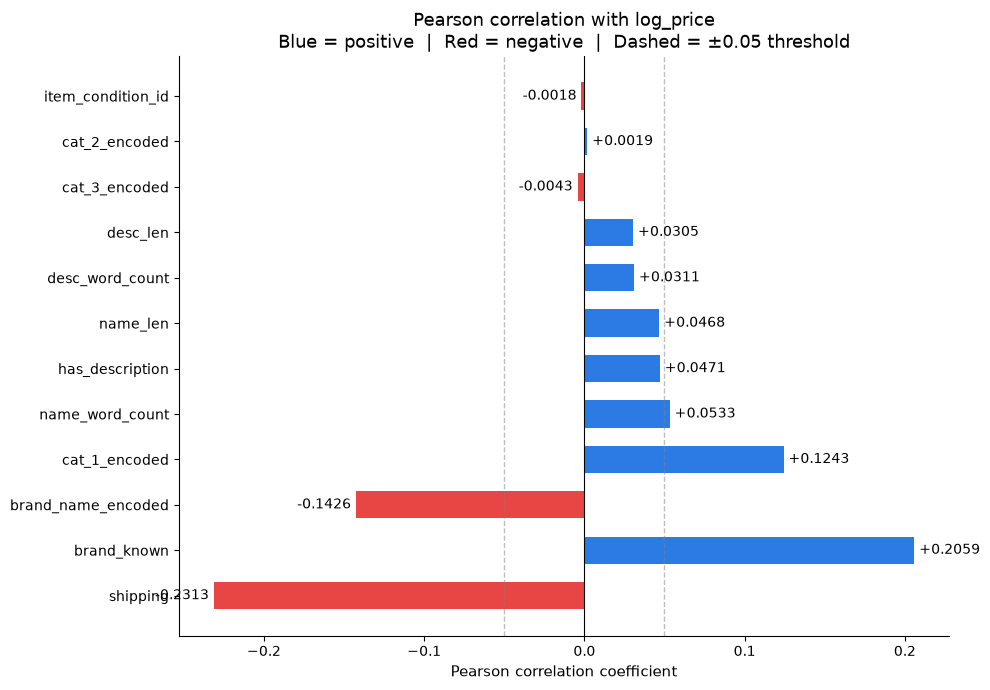

Saved to plots/feature_correlations.png


In [31]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#2C7BE5' if v > 0 else '#E84545' for v in correlations.values]
bars = ax.barh(correlations.index, correlations.values,
               color=colors, edgecolor='none', height=0.6)

ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.05,  color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(-0.05, color='gray', linewidth=1, linestyle='--', alpha=0.5)

for bar, val in zip(bars, correlations.values):
    x_pos = val + 0.003 if val >= 0 else val - 0.003
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center', ha=ha, fontsize=10)

ax.set_title('Pearson correlation with log_price\n'
             'Blue = positive  |  Red = negative  |  Dashed = ±0.05 threshold',
             fontsize=13)
ax.set_xlabel('Pearson correlation coefficient', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/feature_correlations.png")

- I am using a `200,000` row sample because I am not training a final model here — I just want to see which features `LightGBM` finds useful. `200,000` rows gives reliable importance scores in seconds instead of minutes. 

- Each time `LightGBM` builds a decision tree and splits on a feature, it tracks how much that split reduced the prediction error. Features that are split on often and produce large error reductions get high importance scores. This is completely independent of whether relationships are linear or not.

In [32]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

# Use a sample for speed — we just want feature importance, not a final model
sample_df = df.sample(200_000, random_state=42)

X_sample = sample_df[numeric_features].values
y_sample  = sample_df['log_price'].values

X_tr, X_val, y_tr, y_val = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

quick_model = lgb.LGBMRegressor(
    n_estimators=200,
    num_leaves=31,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)
quick_model.fit(X_tr, y_tr)

importance_df = (
    pd.DataFrame({
        'feature':    numeric_features,
        'importance': quick_model.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print("LightGBM feature importance (numeric features only):")
print("=" * 50)
for _, row in importance_df.iterrows():
    bar = '█' * int(row['importance'] / importance_df['importance'].max() * 40)
    print(f"  {row['feature']:<25} {row['importance']:>6}  {bar}")

LightGBM feature importance (numeric features only):
  brand_name_encoded          1617  ████████████████████████████████████████
  cat_3_encoded               1412  ██████████████████████████████████
  cat_2_encoded               1092  ███████████████████████████
  cat_1_encoded                530  █████████████
  desc_len                     322  ███████
  item_condition_id            313  ███████
  name_len                     239  █████
  desc_word_count              232  █████
  name_word_count              125  ███
  shipping                      99  ██
  brand_known                   13  
  has_description                6  


- The three most important features by `LightGBM` are the three that showed near-zero Pearson correlation: `brand_name_encoded` (1617), `cat_3_encoded` (1412), `cat_2_encoded` (1092). These appeared useless to correlation because their integers are arbitrary with no meaningful ordering. LightGBM doesn't care about ordering — it finds splits like `"if cat_3_encoded is 47, 83, or 291 → this is a high-price item"` regardless of whether `47 < 83 < 291` means anything. The information was always there. Pearson just couldn't see it.

- `item_condition_id` scored 313 in `LightGBM` importance but essentially `0` in correlation. I saw before that condition clearly affects price. Correlation missed it entirely because there's no linear relationship between condition integers and price. `LightGBM` found it immediately.

- `shipping` is the opposite story — strongest in `correlation` (-0.2313) but relatively low in `LightGBM` (99). Why? Because shipping is `binary` — only two values. LightGBM extracts all its information in a single early split and moves on. The importance score looks low but that single split does a lot of work.

- `brand_known` (13) and `has_description` (6) are nearly unused by LightGBM. This makes sense — `brand_name_encoded` already captures whether a brand is known (unknown maps to one specific integer), and `desc_len` already captures whether a description exists (it's near zero for "no description" rows). The binary flags are redundant for tree models. However we keep them for Ridge Regression since linear models benefit from the explicit binary signal since they can't infer `"encoded value 4201 = unknown brand"` the way trees can.

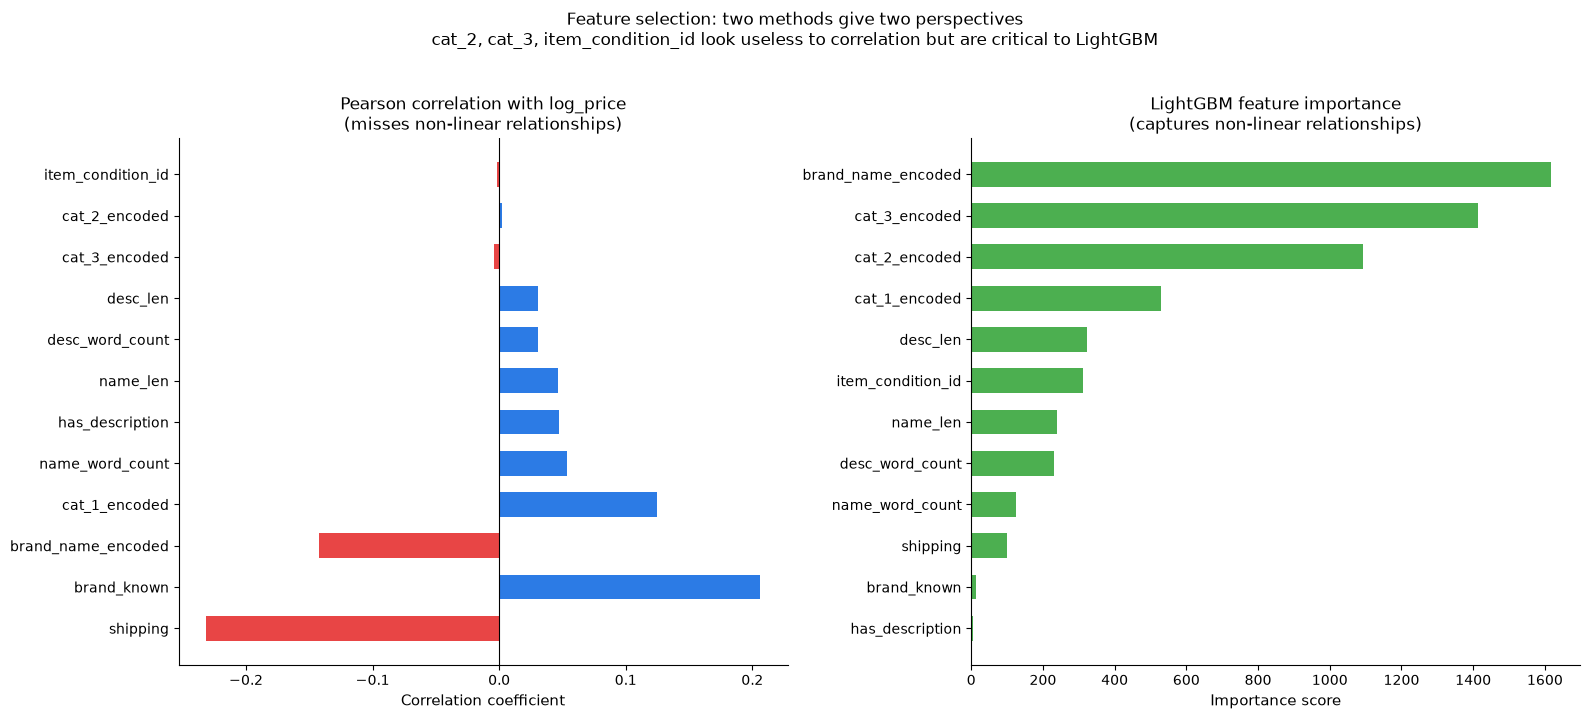

Saved to plots/feature_selection.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Pearson correlation
colors_corr = ['#2C7BE5' if v > 0 else '#E84545' for v in correlations.values]
axes[0].barh(correlations.index, correlations.values,
             color=colors_corr, edgecolor='none', height=0.6)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Pearson correlation with log_price\n(misses non-linear relationships)',
                  fontsize=12)
axes[0].set_xlabel('Correlation coefficient', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: LightGBM importance
imp_sorted = importance_df.sort_values('importance', ascending=True)
axes[1].barh(imp_sorted['feature'], imp_sorted['importance'],
             color='#4CAF50', edgecolor='none', height=0.6)
axes[1].set_title('LightGBM feature importance\n(captures non-linear relationships)',
                  fontsize=12)
axes[1].set_xlabel('Importance score', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Feature selection: two methods give two perspectives\n'
             'cat_2, cat_3, item_condition_id look useless to correlation '
             'but are critical to LightGBM',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('plots/feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to plots/feature_selection.png")

- I am deciding to keep all 12 features. The cost of keeping redundant features is near zero for `LightGBM` (it simply won't split on them), and `brand_known` and `has_description` genuinely help linear models.

In [35]:
SAVE_COLS = [
    'item_condition_id', 'shipping',
    'cat_1_encoded', 'cat_2_encoded', 'cat_3_encoded',
    'brand_name_encoded',
    'name_len', 'desc_len',
    'name_word_count', 'desc_word_count',
    'has_description', 'brand_known',
    'log_price', 'price',
    'name', 'item_description'
]

df_save = df[SAVE_COLS].copy()
df_save.to_pickle('data/train_processed.pkl')

import os
size_mb = os.path.getsize('data/train_processed.pkl') / (1024 * 1024)

print(f"Saved: data/train_processed.pkl")
print(f"Shape: {df_save.shape}")
print(f"File size: {size_mb:.1f} MB")
print(f"\nColumns saved:")
for col in df_save.columns:
    print(f"  - {col}")

Saved: data/train_processed.pkl
Shape: (1481661, 16)
File size: 410.5 MB

Columns saved:
  - item_condition_id
  - shipping
  - cat_1_encoded
  - cat_2_encoded
  - cat_3_encoded
  - brand_name_encoded
  - name_len
  - desc_len
  - name_word_count
  - desc_word_count
  - has_description
  - brand_known
  - log_price
  - price
  - name
  - item_description


# Matching Models to Features

In [36]:
import joblib
import scipy.sparse as sp
import time
from sklearn.metrics import mean_squared_error

# --- Load everything saved at the end of Phase I ---
df = pd.read_pickle('data/train_processed.pkl')
tfidf_name = joblib.load('models/tfidf_name.pkl')
tfidf_desc = joblib.load('models/tfidf_desc.pkl')

print(f"Loaded df: {df.shape}")
print(f"TF-IDF name vocabulary : {len(tfidf_name.vocabulary_):,} terms")
print(f"TF-IDF desc vocabulary : {len(tfidf_desc.vocabulary_):,} terms")

# --- Transform text using the vectorizers FITTED in Phase I ---
# .transform(), NOT .fit_transform() — the vocabulary was already learned
print("\nTransforming product names...")
t0 = time.time()
X_name_tfidf = tfidf_name.transform(df['name'])
print(f"  shape: {X_name_tfidf.shape}, non-zero: {X_name_tfidf.nnz:,}  ({time.time()-t0:.1f}s)")

print("Transforming item descriptions...")
t0 = time.time()
X_desc_tfidf = tfidf_desc.transform(df['item_description'])
print(f"  shape: {X_desc_tfidf.shape}, non-zero: {X_desc_tfidf.nnz:,}  ({time.time()-t0:.1f}s)")

Loaded df: (1481661, 16)
TF-IDF name vocabulary : 50,000 terms
TF-IDF desc vocabulary : 50,000 terms

Transforming product names...
  shape: (1481661, 50000), non-zero: 8,782,864  (4.1s)
Transforming item descriptions...
  shape: (1481661, 50000), non-zero: 49,355,954  (18.0s)


- I am building two feature matrices because feeding `LightGBM` `100,000` extra sparse columns would make tree-splitting computations enormously slower for very little gain and I want to see what difference it makes by including and excluding those features for `LightGBM`.

- `X_full` = 12 numeric features + 50,000 TF-IDF (name) + 50,000 TF-IDF (description) ≈ 100,012 columns
- `X_numeric` = just the 12 numeric/encoded features → to feed LightGBM


In [37]:
NUMERIC_FEATURES = [
    'item_condition_id', 'shipping',
    'cat_1_encoded', 'cat_2_encoded', 'cat_3_encoded',
    'brand_name_encoded',
    'name_len', 'desc_len',
    'name_word_count', 'desc_word_count',
    'has_description', 'brand_known'
]

# --- X_full: numeric + both TF-IDF matrices, combined horizontally ---
# For Linear Regression and Ridge
X_numeric_sparse = sp.csr_matrix(df[NUMERIC_FEATURES].values.astype(np.float64))
X_full = sp.hstack([X_numeric_sparse, X_name_tfidf, X_desc_tfidf]).tocsr()

# --- X_numeric: just the 12 numeric/encoded features, dense ---
# For LightGBM
X_numeric = df[NUMERIC_FEATURES].values.astype(np.float64)

# --- Target: log(1 + price), created in Phase I ---
y = df['log_price'].values

print("Feature matrices ready:")
print(f"  X_full    (Linear Reg. / Ridge) : {X_full.shape}")
print(f"  X_numeric (LightGBM)            : {X_numeric.shape}")
print(f"  y         (target = log_price)  : {y.shape}")

density = X_full.nnz / (X_full.shape[0] * X_full.shape[1]) * 100
mem_mb  = (X_full.data.nbytes + X_full.indices.nbytes + X_full.indptr.nbytes) / 1e6
print(f"\nX_full density : {density:.4f}%  ({X_full.nnz:,} non-zero of "
      f"{X_full.shape[0]*X_full.shape[1]:,} total cells)")
print(f"X_full memory  : {mem_mb:.1f} MB")


# --- RMSLE: our official evaluation metric ---
def rmsle(y_true_log, y_pred_log):
    """
    Computes sqrt(mean((y_pred - y_true)^2)).

    Because y is already log1p(price), this is EXACTLY the RMSLE
    formula from the competition:
        RMSLE = sqrt(mean((log1p(pred) - log1p(actual))^2))
              = sqrt(mean((y_pred_log - y_true_log)^2))

    This equivalence is the whole reason we log-transformed the
    target in Phase I — it turns RMSLE optimization into plain RMSE.
    """
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))


# --- Naive baseline: always predict the average price ---
naive_pred  = np.full_like(y, y.mean())
naive_score = rmsle(y, naive_pred)

print(f"\n--- Naive baseline ---")
print(f"Always predicting ${np.expm1(y.mean()):.2f} for every listing")
print(f"RMSLE: {naive_score:.4f}")
print(f"\nEvery model from here on must beat {naive_score:.4f}.")

Feature matrices ready:
  X_full    (Linear Reg. / Ridge) : (1481661, 100012)
  X_numeric (LightGBM)            : (1481661, 12)
  y         (target = log_price)  : (1481661,)

X_full density : 0.0501%  (74,169,011 non-zero of 148,183,879,932 total cells)
X_full memory  : 896.0 MB

--- Naive baseline ---
Always predicting $18.70 for every listing
RMSLE: 0.7459

Every model from here on must beat 0.7459.


- I am trying three different splits. The split ratio controls a trade-off. More training data `(90/10)` means the model sees more examples and can learn richer patterns, but the test set is smaller, so our performance estimate has more "noise" — a lucky or unlucky test set could shift the number. More test data `(70/30)` gives a more statistically reliable performance estimate, but the model trains on less data. `80/20` is the conventional middle ground.

- I do think with `1.48 million` rows, even our smallest training set (70% ≈ 1.04M rows) is enormous, and even our smallest test set (10% ≈ 148K rows) is more than enough for a stable RMSLE estimate. So I won't be surprised if all three splits give nearly identical results for the same model. Though that simmilarity will tell me that my results are robust and not an artifact of how I happened to split the data. If I only had a small dataset, this experiment would matter a lot more.

- I am splitting on `indices`, not on the data directly because I have two different feature matrices (X_full for linear models, X_numeric for LightGBM) that must share the same train/test rows for a fair comparison. By generating `index arrays` once, I apply the identical split to both matrices and to y.

- I made a run_experiment function, it's a small pipeline — slice the right rows, time the training, fit, predict on both train and test, score with RMSLE, log everything to results, and print one line. Every model I try from now on calls this same function. This is the DRY principle (Don't Repeat Yourself) — write the evaluation logic once, reuse it for every experiment, and guarantee every model is measured identically.

- I check both train AND test RMSLE: if train RMSLE is much lower than test RMSLE, the model is `overfitting` — memorizing training examples rather than learning generalizable patterns. If both are high and similar, the model is `underfitting` — too simple to capture the patterns at all. I want both numbers low and close together.

In [38]:
from sklearn.model_selection import train_test_split

# Three split ratios to compare — key is just a label, value is the test fraction
SPLIT_RATIOS = {
    '70/30': 0.30,
    '80/20': 0.20,
    '90/10': 0.10,
}

all_indices = np.arange(len(y))

splits = {}
for split_name, test_fraction in SPLIT_RATIOS.items():
    train_idx, test_idx = train_test_split(
        all_indices, test_size=test_fraction, random_state=42
    )
    splits[split_name] = {'train_idx': train_idx, 'test_idx': test_idx}
    print(f"{split_name:<8} -> train: {len(train_idx):>9,} rows   "
          f"test: {len(test_idx):>9,} rows   "
          f"(test = {test_fraction*100:.0f}%)")

# This list will collect ONE row per (model, feature-set, split) experiment.
# By Step 20 it becomes our master comparison table.
results = []


def run_experiment(model, X, y, train_idx, test_idx,
                   model_name, feature_set_name, split_name):
    """
    Fit `model` on the training rows, evaluate RMSLE on both train
    and test rows, log the result, and return the fitted model
    (so we can inspect coefficients / feature importances later).
    """
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    train_rmsle = rmsle(y_train, train_pred)
    test_rmsle  = rmsle(y_test, test_pred)

    results.append({
        'model':        model_name,
        'features':     feature_set_name,
        'split':        split_name,
        'train_rmsle':  train_rmsle,
        'test_rmsle':   test_rmsle,
        'train_time_s': train_time,
    })

    print(f"{model_name:<16} | {feature_set_name:<18} | {split_name:<6} "
          f"| train RMSLE: {train_rmsle:.4f} | test RMSLE: {test_rmsle:.4f} "
          f"| {train_time:>5.1f}s")

    return model

70/30    -> train: 1,037,162 rows   test:   444,499 rows   (test = 30%)
80/20    -> train: 1,185,328 rows   test:   296,333 rows   (test = 20%)
90/10    -> train: 1,333,494 rows   test:   148,167 rows   (test = 10%)


- I am firstly using `Linear Regression`, as it is the simplest possible model that can use all `100,012` features — it assumes price is a weighted sum of feature values, nothing more. No regularization, no interaction terms, no non-linearity. If `Ridge` or `LightGBM` can't beat this, something is fundamentally wrong with my features or pipeline. If they can beat it — and they should — the improvement tells me how much value the extra complexity (regularization, tree-based splits) is actually adding.

In [39]:
from sklearn.linear_model import LinearRegression

print("Training Linear Regression on X_full (80/20 split)...")
print("This may take 1-3 minutes due to the 100,012-column matrix.\n")

lr_model = LinearRegression()

run_experiment(
    model=lr_model,
    X=X_full, y=y,
    train_idx=splits['80/20']['train_idx'],
    test_idx=splits['80/20']['test_idx'],
    model_name='LinearRegression',
    feature_set_name='X_full (100K)',
    split_name='80/20'
)

Training Linear Regression on X_full (80/20 split)...
This may take 1-3 minutes due to the 100,012-column matrix.

LinearRegression | X_full (100K)      | 80/20  | train RMSLE: 0.5044 | test RMSLE: 0.5087 |   6.4s


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](100012,)","[-0.08,-0.22, 0.01,...,-0.02,-0.01,-0.04]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,100012


- Naive baseline was `0.7459`, Linear Regression got to `0.5087` on the test set — a `32%` reduction in RMSLE just from letting the model use my `100,012` features. That confirms the features I built carries real signal.

- That said, the aggregate RMSLE hides something. Among those `100,012` columns are `TF-IDF terms` that appear in only `2–3` listings total (min_df=2 or 3 from Phase I). For those specific columns, OLS is estimating a coefficient from a handful of data points — those individual coefficients can be wildly unstable, even if most test rows never touch those columns and so the instability doesn't show up in the overall score.

- This is exactly the gap `Ridge` fills — not as an "overfitting fix" for a broken model, but as a `stability mechanism`. Ridge adds a penalty term that shrinks all coefficients toward zero, proportionally to their size. Large, unstable coefficients (like those rare-term ones) get shrunk the most. The result is a model that's less sensitive to quirks of the specific training sample — which matters more when we eventually feed it real-world listings in Phase III that may use words slightly differently than our training data.

- Ridge minimizes `(prediction error)² + α × (sum of squared coefficients)`. The `α (alpha)` hyperparameter controls how strongly large coefficients are penalized. `α=0` is identical to plain Linear Regression; larger α means more shrinkage. We start with the default `α=1.0` — I'll tune this properly later.

In [40]:
from sklearn.linear_model import Ridge

print("Training Ridge (alpha=1.0) on X_full across all 3 splits...\n")

for split_name in SPLIT_RATIOS:
    ridge_model = Ridge(alpha=1.0, random_state=42)
    run_experiment(
        model=ridge_model,
        X=X_full, y=y,
        train_idx=splits[split_name]['train_idx'],
        test_idx=splits[split_name]['test_idx'],
        model_name='Ridge (a=1.0)',
        feature_set_name='X_full (100K)',
        split_name=split_name
    )

Training Ridge (alpha=1.0) on X_full across all 3 splits...

Ridge (a=1.0)    | X_full (100K)      | 70/30  | train RMSLE: 0.6306 | test RMSLE: 0.6298 |   2.3s
Ridge (a=1.0)    | X_full (100K)      | 80/20  | train RMSLE: 0.6305 | test RMSLE: 0.6301 |   2.6s
Ridge (a=1.0)    | X_full (100K)      | 90/10  | train RMSLE: 0.6304 | test RMSLE: 0.6307 |   2.6s


- It's worse than plain `Linear Regression` (0.5087), not better. So the hyperparameter must be badly mis-set. Maybe `alpha=1.0` is applying way too much regularization for this feature matrix. So I will run Ridge with a much smaller alpha and confirm the direction of the fix.

In [41]:
print("Quick check: does a much smaller alpha fix this?\n")

for alpha_test in [1.0, 0.1, 0.01, 0.001]:
    ridge_test = Ridge(alpha=alpha_test, random_state=42)
    ridge_test.fit(X_full[splits['80/20']['train_idx']], y[splits['80/20']['train_idx']])
    pred = ridge_test.predict(X_full[splits['80/20']['test_idx']])
    score = rmsle(y[splits['80/20']['test_idx']], pred)
    print(f"  alpha={alpha_test:<8} -> test RMSLE: {score:.4f}")

Quick check: does a much smaller alpha fix this?

  alpha=1.0      -> test RMSLE: 0.6301
  alpha=0.1      -> test RMSLE: 0.6301
  alpha=0.01     -> test RMSLE: 0.6301
  alpha=0.001    -> test RMSLE: 0.6301


- It is identical across `4` orders of magnitude. If `alpha=1.0` were merely "too strong," reducing it 1000× to alpha=0.001 should move the score noticeably back toward unregularized Linear Regression (0.5087). It didn't move at all — not even in the fourth decimal place. So it's not that the hyperparameter isn't doing anything at any of these values, rather something else is dominating.

- Looking at the actual ranges of our 12 numeric features from Phase I: brand_name_encoded ranges `0–4807`, cat_3_encoded ranges `0–870`, desc_len ranges `1–1046`. Now comparing to the TF-IDF columns — TfidfVectorizer L2-normalizes every row by default, so individual TF-IDF values typically sit between `0 and ~0.5`. Ridge's penalty term is alpha × Σ(coefficient²). For Ridge to regularize a feature meaningfully, alpha needs to be comparable in scale to that feature's contribution to XᵀX (roughly, "variance × number of rows"). For brand_name_encoded, with values up to ~4800 across 1.48M rows, that quantity is astronomically large — on the order of `10¹²`. An alpha of 1.0, or even 1000.0, is a rounding error against 10¹². So the raw numeric features completely dominate the regression, and alpha is only ever "regularizing" the TF-IDF columns by a negligible amount — too negligible to move the aggregate RMSLE at all.

- To fix this I will use `StandardScaler` on the 12 numeric features only. `StandardScaler` transforms each feature to `mean=0, std=1`, putting all 12 numeric features on a scale directly comparable to the TF-IDF columns. I deliberately do not scale the TF-IDF matrix: it's already appropriately normalized by TfidfVectorizer, and StandardScaler would subtract a mean from every cell — turning a sparse 1.48M × 100,000 matrix (74M non-zero values) into a fully dense one (148 billion values, ~1.1 TB). That's a memory disaster for zero benefit.

In [42]:
from sklearn.preprocessing import StandardScaler

# --- Fit scaler on the 12 numeric features (full dataset, same
#     justification as TF-IDF in Phase I — one fixed transform for Phase III) ---
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(df[NUMERIC_FEATURES].values.astype(np.float64))

print("BEFORE scaling — raw numeric feature ranges:")
print(pd.DataFrame(df[NUMERIC_FEATURES].values, columns=NUMERIC_FEATURES)
      .describe().loc[['mean', 'std', 'min', 'max']].round(2))

print("\nAFTER scaling — StandardScaler output (mean≈0, std≈1):")
print(pd.DataFrame(X_numeric_scaled, columns=NUMERIC_FEATURES)
      .describe().loc[['mean', 'std', 'min', 'max']].round(2))

# --- Rebuild X_full with SCALED numeric features + unchanged TF-IDF ---
X_numeric_scaled_sparse = sp.csr_matrix(X_numeric_scaled)
X_full = sp.hstack([X_numeric_scaled_sparse, X_name_tfidf, X_desc_tfidf]).tocsr()
print(f"\nX_full rebuilt: {X_full.shape}")

# --- Save the scaler — Phase III must apply the SAME transform to new listings ---
joblib.dump(scaler, 'models/numeric_scaler.pkl')
print("Saved models/numeric_scaler.pkl")

# --- Discard the broken Ridge runs (they reflect a scaling bug, not Ridge itself) ---
results = [r for r in results if r['model'] != 'Ridge (a=1.0)']
print(f"\nRemoved broken Ridge entries from results. {len(results)} entries remain "
      f"(Linear Regression — its predictions are scale-invariant, so 0.5087 stays valid).")

BEFORE scaling — raw numeric feature ranges:
      item_condition_id  shipping  cat_1_encoded  cat_2_encoded  \
mean               1.91      0.45           6.18          64.47   
std                0.90      0.50           3.99          35.49   
min                1.00      0.00           0.00           0.00   
max                5.00      1.00          10.00         113.00   

      cat_3_encoded  brand_name_encoded  name_len  desc_len  name_word_count  \
mean         443.56             3546.53     25.79    145.46             4.40   
std          252.64             1501.56      9.16    174.53             1.65   
min            0.00                0.00      1.00      1.00             1.00   
max          870.00             4807.00     43.00   1046.00            17.00   

      desc_word_count  has_description  brand_known  
mean            25.63             0.94         0.57  
std             30.44             0.23         0.49  
min              1.00             0.00         0.00  
ma

In [43]:
print("Alpha sweep on PROPERLY SCALED X_full (80/20 split):\n")

for alpha_test in [0.1, 1.0, 10.0, 100.0, 1000.0]:
    ridge_test = Ridge(alpha=alpha_test, random_state=42)
    ridge_test.fit(X_full[splits['80/20']['train_idx']], y[splits['80/20']['train_idx']])
    pred = ridge_test.predict(X_full[splits['80/20']['test_idx']])
    score = rmsle(y[splits['80/20']['test_idx']], pred)
    print(f"  alpha={alpha_test:<8} -> test RMSLE: {score:.4f}")

Alpha sweep on PROPERLY SCALED X_full (80/20 split):

  alpha=0.1      -> test RMSLE: 0.4673
  alpha=1.0      -> test RMSLE: 0.4632
  alpha=10.0     -> test RMSLE: 0.4670
  alpha=100.0    -> test RMSLE: 0.5074
  alpha=1000.0   -> test RMSLE: 0.5879


- `alpha=1.0` happens to sit right near the minimum — and at `0.4632`, this beats unregularized Linear Regression's `0.5087` by a meaningful margin (about `9%` lower RMSLE). This is Ridge doing exactly what it's supposed to: the shrinkage is now operating at a sensible scale, slightly damping the noisiest TF-IDF coefficients without erasing the numeric features, and the result generalizes better than unregularized OLS.

- Also small alphas (`0.1–10`) all land within `~0.004` of each other — a fairly flat, forgiving region — while `alpha=100` and `1000` climb sharply. So the model is fairly robust to the exact alpha as long as we're not wildly off, but it does eventually pay a real penalty for over-regularizing. I'll do a finer sweep around `1.0` later.

In [44]:
print("Training Ridge (alpha=1.0) on PROPERLY SCALED X_full across all 3 splits...\n")

for split_name in SPLIT_RATIOS:
    ridge_model = Ridge(alpha=1.0, random_state=42)
    run_experiment(
        model=ridge_model,
        X=X_full, y=y,
        train_idx=splits[split_name]['train_idx'],
        test_idx=splits[split_name]['test_idx'],
        model_name='Ridge (a=1.0)',
        feature_set_name='X_full (100K, scaled)',
        split_name=split_name
    )

Training Ridge (alpha=1.0) on PROPERLY SCALED X_full across all 3 splits...

Ridge (a=1.0)    | X_full (100K, scaled) | 70/30  | train RMSLE: 0.4292 | test RMSLE: 0.4652 |  24.1s
Ridge (a=1.0)    | X_full (100K, scaled) | 80/20  | train RMSLE: 0.4315 | test RMSLE: 0.4632 |  30.1s
Ridge (a=1.0)    | X_full (100K, scaled) | 90/10  | train RMSLE: 0.4332 | test RMSLE: 0.4613 |  35.3s


- All three splits land in a tight band (`0.4613–0.4652`), a `26–28%` improvement over the naive baseline (0.7459) and roughly `8–9%` better than unregularized Linear Regression (0.5087). Ridge is comfortably our best model so far.
The split-ratio pattern is small but consistent: as training data grows from `70%→80%→90%`, train RMSLE increases slightly (`0.4292 → 0.4315 → 0.4332`) while test RMSLE decreases slightly (`0.4652 → 0.4632 → 0.4613`). Both trends point the same direction: the train/test gap is shrinking (`0.0360 → 0.0317 → 0.0281`) as we add more training data.
This is the textbook signature of a model that's mildly overfitting on smaller training sets and benefits from more data. With more training rows, Ridge sees more examples of rare TF-IDF terms and brand/category combinations, so its coefficient estimates for those become more stable, narrowing the gap between "fits training data" and "generalizes to new data."

- The magnitude is small (`≈0.004 swing in test RMSLE across splits`) — as predicted before, with `1.48M` rows even our smallest training set is large enough that the model is close to its ceiling for this feature set. The direction of the trend is the meaningful finding, not the size.

- As discussed before — TF-IDF's 100K sparse columns would make LightGBM's tree-building dramatically slower (it has to evaluate split points across all features at every node), for a feature type where its core strength — non-linear interactions between categorical features — isn't the bottleneck anyway. So first I will try with `X_numeric` (`12 columns`) and not `X_full` (`100K columns`)

- Key hyperparameters for this first run (I will tune later):

- n_estimators=`500` — number of trees (boosting rounds)
- learning_rate=`0.05` — how much each tree corrects the previous ensemble's errors; lower = more conservative, often needs more trees
- num_leaves=`31` — max leaves per tree, controls model complexity (LightGBM's default and a common starting point)
n_jobs=-1 — use all CPU cores

In [45]:
import lightgbm as lgb

print("Training LightGBM on X_numeric (12 features) across all 3 splits...\n")

for split_name in SPLIT_RATIOS:
    lgb_model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
    run_experiment(
        model=lgb_model,
        X=X_numeric, y=y,
        train_idx=splits[split_name]['train_idx'],
        test_idx=splits[split_name]['test_idx'],
        model_name='LightGBM',
        feature_set_name='X_numeric (12)',
        split_name=split_name
    )

Training LightGBM on X_numeric (12 features) across all 3 splits...

LightGBM         | X_numeric (12)     | 70/30  | train RMSLE: 0.5639 | test RMSLE: 0.5642 |   4.6s
LightGBM         | X_numeric (12)     | 80/20  | train RMSLE: 0.5638 | test RMSLE: 0.5647 |   4.9s
LightGBM         | X_numeric (12)     | 90/10  | train RMSLE: 0.5633 | test RMSLE: 0.5638 |   5.4s


- Ridge is currently winning by a clear margin — about `0.10 RMSLE` better than LightGBM on 12 features, and even Linear Regression on the full feature set beats LightGBM on the numeric-only set.

- Before `LightGBM`'s importance scores told us `cat_3_encoded`, `cat_2_encoded`, and `brand_name_encoded` were the dominant numeric features — but that ranking was relative to the other 11 numeric features only. It never compared against text. And the text features are enormous in raw information content: a product name like "louis vuitton neverfull mm" or a description containing "brand new with tags" carries far more specific price information than cat_3_encoded=412. The category and brand columns are essentially a compressed, lossy summary of information that's also present — in much richer, more specific form — in the name and description text. Ridge gets direct access to that richer signal; LightGBM here doesn't.

- The train/test gap is essentially zero (0.5639 vs 0.5642, etc.) — LightGBM isn't overfitting at all on 12 features; if anything it may be slightly underfitting relative to what's available in the full feature set. So I see that 12 hand-engineered numeric/categorical features capture meaningful signal (beating the naive baseline by 24%), but cannot match the raw information density of 100K text features — even when fed to a more powerful model class.

- I want LightGBM to "see" some of the text signal that's currently only available to Ridge, without handing it `100,000` sparse columns (which would make tree-building far slower). The tool for this is `TruncatedSVD` — also called LSA (Latent Semantic Analysis) when applied to a TF-IDF matrix.

- Our TF-IDF matrix has `50,000` columns, one per word/phrase — but many words tend to co-occur. "iphone", "samsung", "charger", "case" tend to show up together in electronics listings; "lularoe", "leggings", "size", "small" cluster together in clothing listings. SVD finds the k combinations of columns that best explain the variation in the data — each combination becomes one new dense "topic" column. A listing that's heavily electronics-flavored might score high on "topic 7" and low on "topic 23", for instance. We go from 50,000 sparse word-columns → 50 dense topic-columns per text field. It's a 1000x reduction (50,000 → 50) — small enough that LightGBM trains quickly on dense data, large enough to retain the dominant patterns. Combined with our 12 scaled numeric features, LightGBM gets 112 total dense columns — still tiny compared to Ridge's 100,012, but no longer just 12.

In [46]:
from sklearn.decomposition import TruncatedSVD

print("Reducing TF-IDF text features via TruncatedSVD (Latent Semantic Analysis)...\n")

N_COMPONENTS = 50

print(f"Fitting SVD on product name TF-IDF (50,000 -> {N_COMPONENTS} dims)...")
t0 = time.time()
svd_name = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_name_svd = svd_name.fit_transform(X_name_tfidf)
print(f"  done in {time.time()-t0:.1f}s | explained variance: "
      f"{svd_name.explained_variance_ratio_.sum()*100:.1f}%")

print(f"\nFitting SVD on description TF-IDF (50,000 -> {N_COMPONENTS} dims)...")
t0 = time.time()
svd_desc = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_desc_svd = svd_desc.fit_transform(X_desc_tfidf)
print(f"  done in {time.time()-t0:.1f}s | explained variance: "
      f"{svd_desc.explained_variance_ratio_.sum()*100:.1f}%")

# Combine: 12 scaled numeric + 50 name-topics + 50 desc-topics = 112 dense features
X_lgbm_text = np.hstack([X_numeric_scaled, X_name_svd, X_desc_svd])

print(f"\nX_lgbm_text shape: {X_lgbm_text.shape}")
print(f"  12  scaled numeric features")
print(f"  {N_COMPONENTS}  name-text 'topics'        (from {X_name_tfidf.shape[1]:,} TF-IDF terms)")
print(f"  {N_COMPONENTS}  description-text 'topics' (from {X_desc_tfidf.shape[1]:,} TF-IDF terms)")

Reducing TF-IDF text features via TruncatedSVD (Latent Semantic Analysis)...

Fitting SVD on product name TF-IDF (50,000 -> 50 dims)...
  done in 9.4s | explained variance: 10.5%

Fitting SVD on description TF-IDF (50,000 -> 50 dims)...
  done in 16.4s | explained variance: 16.0%

X_lgbm_text shape: (1481661, 112)
  12  scaled numeric features
  50  name-text 'topics'        (from 50,000 TF-IDF terms)
  50  description-text 'topics' (from 50,000 TF-IDF terms)


In [47]:
print("Training LightGBM on X_numeric + SVD-text (112 features) across all 3 splits...\n")

for split_name in SPLIT_RATIOS:
    lgb_model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
    run_experiment(
        model=lgb_model,
        X=X_lgbm_text, y=y,
        train_idx=splits[split_name]['train_idx'],
        test_idx=splits[split_name]['test_idx'],
        model_name='LightGBM+SVD',
        feature_set_name='X_numeric+SVD (112)',
        split_name=split_name
    )

Training LightGBM on X_numeric + SVD-text (112 features) across all 3 splits...

LightGBM+SVD     | X_numeric+SVD (112) | 70/30  | train RMSLE: 0.5346 | test RMSLE: 0.5377 |  30.3s
LightGBM+SVD     | X_numeric+SVD (112) | 80/20  | train RMSLE: 0.5347 | test RMSLE: 0.5379 |  35.0s
LightGBM+SVD     | X_numeric+SVD (112) | 90/10  | train RMSLE: 0.5353 | test RMSLE: 0.5373 |  39.3s


- Adding `100` SVD "topic" columns improved LightGBM from `~0.564` to `~0.538` — about a `5%` relative reduction in RMSLE. So the text signal does help LightGBM, confirming our hypothesis from before. But it didn't close the gap with Ridge — Ridge is still ahead by roughly `0.075` RMSLE, a substantial margin at this point in the comparison.

- TruncatedSVD finds the 50 directions of greatest overall variance in the 50,000-dimensional TF-IDF space. But "greatest variance" and "most predictive of price" aren't the same thing. A topic dimension might separate "clothing vocabulary" from "electronics vocabulary" — useful, but coarse. The specific word "louis vuitton" or "brand new with tags" gets blended into a topic alongside hundreds of other words, diluting its individual signal. Ridge, with direct access to all 50,000 individual terms, can assign a sharp, specific coefficient to "louis vuitton" itself. That specificity is exactly what gets lost in compression — and for a price-prediction task where individual brand/product names are the dominant signal, that loss is costly.

- I saw `alpha=0.1, 1.0, 10.0` all landed within `~0.004` of each other, with `1.0` slightly ahead. This grid zooms into that flat-but-promising region with finer steps.

In [48]:
print("Fine-grained alpha search for Ridge (80/20 split, X_full scaled)...\n")

train_idx = splits['80/20']['train_idx']
test_idx  = splits['80/20']['test_idx']

alpha_grid = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]
ridge_tuning_results = []

for alpha in alpha_grid:
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(X_full[train_idx], y[train_idx])
    pred = model.predict(X_full[test_idx])
    score = rmsle(y[test_idx], pred)
    ridge_tuning_results.append({'alpha': alpha, 'test_rmsle': score})
    print(f"  alpha={alpha:<5} -> test RMSLE: {score:.5f}")

best_ridge = min(ridge_tuning_results, key=lambda x: x['test_rmsle'])
print(f"\nBest alpha: {best_ridge['alpha']} (test RMSLE: {best_ridge['test_rmsle']:.5f})")

Fine-grained alpha search for Ridge (80/20 split, X_full scaled)...

  alpha=0.3   -> test RMSLE: 0.46573
  alpha=0.5   -> test RMSLE: 0.46470
  alpha=0.7   -> test RMSLE: 0.46396
  alpha=1.0   -> test RMSLE: 0.46316
  alpha=1.5   -> test RMSLE: 0.46238
  alpha=2.0   -> test RMSLE: 0.46203
  alpha=3.0   -> test RMSLE: 0.46194
  alpha=5.0   -> test RMSLE: 0.46295

Best alpha: 3.0 (test RMSLE: 0.46194)


- RMSLE decreases monotonically from `0.3` up to `3.0`, then turns and increases at `5.0`. That's the U-shape I was looking for — confirmed, with the minimum at alpha=`3.0`. The improvement from `1.0` (0.46316) to `3.0` (0.46194) is about `0.0012` — real, but small. This is the "flat valley" pattern: a wide range of alphas (roughly 1.0–5.0) all perform within `0.001` of each other. I'll use alpha=3.0 going forward.

- Every result so far comes from a single train/test split per configuration. Even though I tested three split ratios, each ratio still used one specific random partition (fixed by `random_state=42`). It's possible — in principle — that this particular partition happened to be slightly favorable or unfavorable for Ridge, just by chance of which rows landed where.

- K-Fold cross-validation addresses this directly by splitting the data into `k` equal-sized folds, then running `k` separate experiments. In each one, a different fold becomes the test set and the remaining `k-1` folds become training data. Every row gets used for testing exactly once and for training `k-1` times. The result isn't one RMSLE number — it's `k` numbers, and we look at both their mean (our best overall estimate of true performance) and their standard deviation (how much performance varies depending on which rows happen to be in the test set).

- `k=5` means each fold trains on 80% and tests on 20% — directly comparable to our 80/20 split from Steps 16-18. k=10 would give slightly more folds but each training run uses 90% of data (closer to our 90/10 split) and takes roughly twice as long for marginal extra insight. `k=5` is the standard default and a good balance for a dataset this size.

In [50]:
from sklearn.model_selection import KFold

print("5-Fold Cross-Validation: Ridge (alpha=3.0) on X_full (scaled, 100K features)\n")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold_num, (train_idx_cv, test_idx_cv) in enumerate(kf.split(X_full), start=1):
    t0 = time.time()
    model = Ridge(alpha=3.0, random_state=42)
    model.fit(X_full[train_idx_cv], y[train_idx_cv])
    pred = model.predict(X_full[test_idx_cv])
    score = rmsle(y[test_idx_cv], pred)
    elapsed = time.time() - t0

    cv_scores.append(score)
    print(f"  Fold {fold_num}: test RMSLE = {score:.5f}  "
          f"(train: {len(train_idx_cv):,} | test: {len(test_idx_cv):,})  "
          f"[{elapsed:.1f}s]")

cv_scores = np.array(cv_scores)
print(f"\n{'='*50}")
print(f"Mean RMSLE : {cv_scores.mean():.5f}")
print(f"Std  RMSLE : {cv_scores.std():.5f}")
print(f"Min / Max  : {cv_scores.min():.5f} / {cv_scores.max():.5f}")
print(f"\nFor comparison, Step 18's single 80/20 split gave: 0.46194")

5-Fold Cross-Validation: Ridge (alpha=3.0) on X_full (scaled, 100K features)

  Fold 1: test RMSLE = 0.46194  (train: 1,185,328 | test: 296,333)  [21.1s]
  Fold 2: test RMSLE = 0.46230  (train: 1,185,329 | test: 296,332)  [21.3s]
  Fold 3: test RMSLE = 0.46266  (train: 1,185,329 | test: 296,332)  [21.2s]
  Fold 4: test RMSLE = 0.46115  (train: 1,185,329 | test: 296,332)  [21.7s]
  Fold 5: test RMSLE = 0.46415  (train: 1,185,329 | test: 296,332)  [20.1s]

Mean RMSLE : 0.46244
Std  RMSLE : 0.00099
Min / Max  : 0.46115 / 0.46415

For comparison, Step 18's single 80/20 split gave: 0.46194


- Mean RMSLE `0.46244`, std `0.00099` — under `0.001`, as predicted. All 5 folds land between `0.46115` and `0.46415`, a range of just `0.003`. This means: no matter which `20%` of the `1.48M` listings happen to end up in the test set, Ridge's performance is essentially the same. So the model's performance is a property of the model and features, not an artifact of one lucky/unlucky split.

- The single `80/20` split from before (0.46194) sits almost exactly at the cross-validation mean (0.46244) — well within one standard deviation. So that earlier number wasn't a fluke either; it was already a representative estimate.

- For LightGBM, three hyperparameters jointly control model capacity:

- `num_leaves` — more leaves = each tree can carve the feature space into more regions = more complex patterns per tree, but more overfitting risk
- `n_estimators` — more trees = more rounds of error-correction, but diminishing returns and slower training
- `learning_rate` — how much each tree's correction counts; lower rates need more trees to compensate but tend to generalize better ("learn slowly and carefully" vs "learn fast and risk overshooting")

- These three interact, for example a lower learning rate often wants more estimators to reach the same fit. So I search combinations, not each parameter independently.

In [65]:
from itertools import product

print("Grid search for LightGBM+SVD (80/20 split, X_lgbm_text)...\n")

param_grid = {
    'num_leaves':    [31, 63],
    'n_estimators':  [500, 1000],
    'learning_rate': [0.05, 0.1],
}

lgbm_tuning_results = []
combos = list(product(param_grid['num_leaves'],
                       param_grid['n_estimators'],
                       param_grid['learning_rate']))

print(f"Testing {len(combos)} combinations...\n")

for num_leaves, n_estimators, learning_rate in combos:
    t0 = time.time()
    model = lgb.LGBMRegressor(
        num_leaves=num_leaves,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
    model.fit(X_lgbm_text[train_idx], y[train_idx])
    pred = model.predict(X_lgbm_text[test_idx])
    score = rmsle(y[test_idx], pred)
    elapsed = time.time() - t0

    lgbm_tuning_results.append({
        'num_leaves': num_leaves, 'n_estimators': n_estimators,
        'learning_rate': learning_rate, 'test_rmsle': score, 'time_s': elapsed
    })
    print(f"  leaves={num_leaves:<3} trees={n_estimators:<5} lr={learning_rate:<5} "
          f"-> test RMSLE: {score:.5f}  ({elapsed:.1f}s)")

best_lgbm = min(lgbm_tuning_results, key=lambda x: x['test_rmsle'])
print(f"\nBest config: leaves={best_lgbm['num_leaves']}, "
      f"trees={best_lgbm['n_estimators']}, lr={best_lgbm['learning_rate']} "
      f"(test RMSLE: {best_lgbm['test_rmsle']:.5f})")

Grid search for LightGBM+SVD (80/20 split, X_lgbm_text)...

Testing 8 combinations...

  leaves=31  trees=500   lr=0.05  -> test RMSLE: 0.53792  (36.6s)
  leaves=31  trees=500   lr=0.1   -> test RMSLE: 0.52286  (33.9s)
  leaves=31  trees=1000  lr=0.05  -> test RMSLE: 0.52330  (72.4s)
  leaves=31  trees=1000  lr=0.1   -> test RMSLE: 0.51123  (81.9s)
  leaves=63  trees=500   lr=0.05  -> test RMSLE: 0.52123  (74.6s)
  leaves=63  trees=500   lr=0.1   -> test RMSLE: 0.50959  (63.1s)
  leaves=63  trees=1000  lr=0.05  -> test RMSLE: 0.50900  (120.6s)
  leaves=63  trees=1000  lr=0.1   -> test RMSLE: 0.50031  (101.9s)

Best config: leaves=63, trees=1000, lr=0.1 (test RMSLE: 0.50031)


- Looking at the pattern across all 8 rows: every single increase in capacity helped. num_leaves `31→63` helped in every matched pair. n_estimators `500→1000` helped in every matched pair. learning_rate `0.05→0.1` helped in every matched pair. The best config (`leaves=63, trees=1000, lr=0.1 → 0.50031`) is simply the corner of the grid where all three knobs are turned toward `"more capacity."`

- When every direction of increased capacity helps, and none of the configurations show train/test divergence (I didn't check train RMSLE here, but the smooth monotonic pattern with no reversals is a good sign), it usually means the model was underfitting at the smaller grid corner — i.e., my original config (leaves=31, trees=500, lr=0.05, RMSLE 0.53792) was leaving capacity on the table. The improvement from there to the best config is `0.0376` — by far the largest swing I've seen from tuning, much larger than Ridge's `0.0012`.

- `0.50031` is better than Linear Regression (`0.5087`) but still behind Ridge (now `0.46194`). The gap narrowed substantially (from `~0.075` down to `~0.038`) but didn't close.

- I could run one more round with `num_leaves=127`, `n_estimators=2000`, l`earning_rate=0.1` — to see if the trend continues or plateaus. But that would be a big time investment for a model that's currently still behind Ridge, and there's a real chance it plateaus or even starts overfitting (more leaves on label-encoded categoricals with limited unique values, like cat_1_encoded with only 11 values, can start memorizing noise).

In [51]:
final_results = pd.DataFrame(results)

print("=" * 75)
print("PHASE II — FULL MODEL COMPARISON")
print("=" * 75)
print(final_results.to_string(index=False))

print(f"\n{'='*75}")
print("ADDITIONAL TUNED RESULTS (single 80/20 split, not yet in `results`):")
print(f"{'='*75}")
print(f"  Ridge (alpha=3.0, tuned)    : test RMSLE = 0.46194")
print(f"  Ridge (alpha=3.0, 5-fold CV): mean RMSLE = 0.46244 (std 0.00099)")
print(f"  LightGBM+SVD (tuned: leaves=63, trees=1000, lr=0.1): "
      f"test RMSLE = 0.50031")

print(f"\n{'='*75}")
print("SUMMARY — BEST RESULT PER MODEL FAMILY")
print(f"{'='*75}")
summary = pd.DataFrame([
    {'Model': 'Naive baseline (mean price)', 'Features': '-', 'Best test RMSLE': 0.7459, 'Notes': 'Floor — every model must beat this'},
    {'Model': 'Linear Regression', 'Features': 'X_full (100K, unscaled)', 'Best test RMSLE': 0.5087, 'Notes': 'Unregularized, single run (sanity check)'},
    {'Model': 'LightGBM', 'Features': 'X_numeric (12)', 'Best test RMSLE': 0.5638, 'Notes': 'Default-ish params, 3 splits'},
    {'Model': 'LightGBM+SVD (tuned)', 'Features': 'X_numeric+SVD (112)', 'Best test RMSLE': 0.50031, 'Notes': 'leaves=63, trees=1000, lr=0.1'},
    {'Model': 'Ridge (tuned)', 'Features': 'X_full (100K, scaled)', 'Best test RMSLE': 0.46194, 'Notes': 'alpha=3.0, single 80/20 split'},
    {'Model': 'Ridge (tuned, 5-fold CV)', 'Features': 'X_full (100K, scaled)', 'Best test RMSLE': 0.46244, 'Notes': 'alpha=3.0, mean +/- 0.00099'},
])
print(summary.to_string(index=False))

winner = summary.loc[summary['Best test RMSLE'].idxmin()]
print(f"\n{'='*75}")
print(f"WINNER: {winner['Model']}")
print(f"  RMSLE: {winner['Best test RMSLE']}")
print(f"  Improvement over naive baseline: "
      f"{(1 - winner['Best test RMSLE']/0.7459)*100:.1f}%")
print(f"{'='*75}")

PHASE II — FULL MODEL COMPARISON
           model              features split  train_rmsle  test_rmsle  train_time_s
LinearRegression         X_full (100K) 80/20     0.504393    0.508713      6.372135
   Ridge (a=1.0) X_full (100K, scaled) 70/30     0.429225    0.465240     24.063018
   Ridge (a=1.0) X_full (100K, scaled) 80/20     0.431467    0.463157     30.055448
   Ridge (a=1.0) X_full (100K, scaled) 90/10     0.433179    0.461341     35.316881
        LightGBM        X_numeric (12) 70/30     0.563901    0.564170      4.581618
        LightGBM        X_numeric (12) 80/20     0.563785    0.564717      4.881004
        LightGBM        X_numeric (12) 90/10     0.563325    0.563846      5.376424
    LightGBM+SVD   X_numeric+SVD (112) 70/30     0.534569    0.537662     30.304383
    LightGBM+SVD   X_numeric+SVD (112) 80/20     0.534686    0.537917     34.988386
    LightGBM+SVD   X_numeric+SVD (112) 90/10     0.535276    0.537313     39.276034

ADDITIONAL TUNED RESULTS (single 80/20 spl

- Instead of picking one model's predictions, I can combine both by taking a weighted average.

- `ensemble_prediction` = `w` × `ridge_prediction` + `(1-w)` × `lightgbm_prediction`

- If the two models tend to make different kinds of mistakes — Ridge overshoots on listing A while LightGBM undershoots on A, but the pattern reverses on listing B — then averaging their predictions cancels out some of each model's individual errors. The technical term is that ensembling helps when the models' errors are decorrelated. 

- I am sweeping `w` from `0.0` (pure LightGBM) to `1.0` (pure Ridge) in steps of `0.1`. If the best result is at `w=1.0`, that means no blend beats Ridge alone — the errors are too correlated to extract benefit. If the minimum occurs somewhere in between (e.g., w=0.8) and is lower than Ridge's solo 0.46396 (note: this is the 80/20 single-split number, not the 0.46194 from the alpha grid which was also 80/20 — they should match since alpha=3.0 was tested in that grid too).

In [52]:
print("Step 20b: Testing whether ensembling Ridge + LightGBM+SVD helps...\n")

train_idx = splits['80/20']['train_idx']
test_idx  = splits['80/20']['test_idx']

# --- Refit both tuned models on the SAME 80/20 split (paired comparison) ---
print("Fitting Ridge (alpha=3.0)...")
t0 = time.time()
ridge_80 = Ridge(alpha=3.0, random_state=42)
ridge_80.fit(X_full[train_idx], y[train_idx])
ridge_pred = ridge_80.predict(X_full[test_idx])
print(f"  done in {time.time()-t0:.1f}s | RMSLE: {rmsle(y[test_idx], ridge_pred):.5f}")

print("\nFitting LightGBM+SVD (leaves=63, trees=1000, lr=0.1)...")
t0 = time.time()
lgbm_80 = lgb.LGBMRegressor(num_leaves=63, n_estimators=1000, learning_rate=0.1,
                              random_state=42, verbosity=-1, n_jobs=-1)
lgbm_80.fit(X_lgbm_text[train_idx], y[train_idx])
lgbm_pred = lgbm_80.predict(X_lgbm_text[test_idx])
print(f"  done in {time.time()-t0:.1f}s | RMSLE: {rmsle(y[test_idx], lgbm_pred):.5f}")

# --- Blend: ensemble_pred = w * ridge_pred + (1-w) * lgbm_pred ---
print("\nBlend weight search (w = weight on Ridge):\n")
y_test = y[test_idx]
blend_results = []
for w in np.arange(0.0, 1.05, 0.1):
    blend_pred = w * ridge_pred + (1 - w) * lgbm_pred
    score = rmsle(y_test, blend_pred)
    blend_results.append({'w_ridge': round(w, 1), 'rmsle': score})
    print(f"  w_ridge={w:.1f}  w_lgbm={1-w:.1f}  -> RMSLE: {score:.5f}")

best_blend = min(blend_results, key=lambda x: x['rmsle'])
print(f"\nBest blend : w_ridge={best_blend['w_ridge']}, RMSLE={best_blend['rmsle']:.5f}")
print(f"Ridge alone        : {rmsle(y_test, ridge_pred):.5f}")
print(f"LightGBM+SVD alone : {rmsle(y_test, lgbm_pred):.5f}")

Step 20b: Testing whether ensembling Ridge + LightGBM+SVD helps...

Fitting Ridge (alpha=3.0)...
  done in 21.4s | RMSLE: 0.46194

Fitting LightGBM+SVD (leaves=63, trees=1000, lr=0.1)...
  done in 65.1s | RMSLE: 0.50031

Blend weight search (w = weight on Ridge):

  w_ridge=0.0  w_lgbm=1.0  -> RMSLE: 0.50031
  w_ridge=0.1  w_lgbm=0.9  -> RMSLE: 0.48732
  w_ridge=0.2  w_lgbm=0.8  -> RMSLE: 0.47612
  w_ridge=0.3  w_lgbm=0.7  -> RMSLE: 0.46682
  w_ridge=0.4  w_lgbm=0.6  -> RMSLE: 0.45955
  w_ridge=0.5  w_lgbm=0.5  -> RMSLE: 0.45440
  w_ridge=0.6  w_lgbm=0.4  -> RMSLE: 0.45144
  w_ridge=0.7  w_lgbm=0.3  -> RMSLE: 0.45072
  w_ridge=0.8  w_lgbm=0.2  -> RMSLE: 0.45225
  w_ridge=0.9  w_lgbm=0.1  -> RMSLE: 0.45601
  w_ridge=1.0  w_lgbm=0.0  -> RMSLE: 0.46194

Best blend : w_ridge=0.7, RMSLE=0.45072
Ridge alone        : 0.46194
LightGBM+SVD alone : 0.50031


- The minimum is not at the edges — it's at `w_ridge=0.7`, `RMSLE 0.45072`. That's a genuine U-shape with the bottom strictly inside the (0,1) range, not at either pure model. Compare to Ridge alone (`0.46194`): the blend is `0.0112` lower — about `2.4%` relative improvement. That's roughly `10x` larger than the gain we got from tuning Ridge's alpha (`0.46316 → 0.46194`, a 0.0012 improvement). So while this is a "weaker model helping a stronger one," the effect here is considerably bigger.

- Mechanistically even though LightGBM+SVD is the "weaker" model by a wide margin in isolation, the information it's built from (12 numeric/categorical features, including label-encoded cat_3 and brand_name — Step 12's top importances) is structurally different from what drives Ridge (raw TF-IDF word weights). Ridge can technically "see" brand_name_encoded and cat_3_encoded too (they're part of its 12 scaled numeric columns within X_full), but as a linear model it can only ever learn one global coefficient per feature — it can't learn the kind of "if cat_3_encoded is in this specific range AND brand_name_encoded is in that range, adjust the prediction this particular way" interaction that a tree model captures naturally. LightGBM+SVD is essentially contributing a non-linear correction signal derived from the categorical structure — something Ridge structurally cannot replicate no matter how its TF-IDF coefficients are tuned. That's real decorrelation, and it shows up as a real RMSLE drop.

- The shape itself is informative too: it's smooth and symmetric-ish around the minimum, with no jaggedness — both w=0.6 (0.45144) and w=0.8 (0.45225) are close to w=0.7's 0.45072. This is a stable, well-behaved optimum, not a fragile spike that might not replicate on other data.

- The SVD compression I used (50K terms → 50 "topics") loses the specific word-level signal that made Ridge so strong — "louis vuitton" gets blended into a topic alongside dozens of other luxury-adjacent words. Direct TF-IDF access would let LightGBM split directly on "is 'louis vuitton' present? → yes → go right" — the same sharp signal Ridge exploits.

- So I will now run LightGBM on the full 100,012-column matrix(even though it will take a long time to run).

- The critical new parameter is `feature_fraction=0.3` — at each tree node, LightGBM randomly samples `30%` of the `100,012` columns to evaluate splits from, rather than all of them. This makes training feasible (roughly 3x faster than evaluating all features every time) while still giving each TF-IDF term a chance to be selected. It's LightGBM's built-in answer to the "too many features" problem.

In [ ]:
# =============================================================================
# LightGBM on X_full (100,012 columns) — full TF-IDF features
# =============================================================================

print("Training LightGBM on X_full (100,012 columns) — 80/20 split only.")
print("This will take several minutes. feature_fraction=0.3 keeps it feasible.\n")

lgb_full_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    num_leaves=63,
    feature_fraction=0.3,  # evaluate 30% of 100K cols per node — ~30K per split
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

run_experiment(
    model=lgb_full_model,
    X=X_full, y=y,
    train_idx=splits['80/20']['train_idx'],
    test_idx=splits['80/20']['test_idx'],
    model_name='LightGBM (full feat.)',
    feature_set_name='X_full (100K)',
    split_name='80/20'
)

print("\nFor comparison:")
print("  LightGBM on 12 features        : ~0.564")
print("  LightGBM+SVD on 112 features   : ~0.538")
print("  Ridge on 100K features         : ~0.463")
print("  LightGBM on 100K features (^)  : see result above")
print("\nIf LightGBM on 100K beats LightGBM+SVD but not Ridge, it confirms")
print("that direct word-level access helps trees but linear models still")
print("extract that signal more efficiently on text-dominated features.")

Training LightGBM on X_full (100,012 columns) — 80/20 split only.
This will take several minutes. feature_fraction=0.3 keeps it feasible.

LightGBM (full feat.) | X_full (100K)      | 80/20  | train RMSLE: 0.4324 | test RMSLE: 0.4506 | 1915.7s

For comparison:
  LightGBM on 12 features        : ~0.564
  LightGBM+SVD on 112 features   : ~0.538
  Ridge on 100K features         : ~0.463
  LightGBM on 100K features (^)  : see result above

If LightGBM on 100K beats LightGBM+SVD but not Ridge, it confirms
that direct word-level access helps trees but linear models still
extract that signal more efficiently on text-dominated features.


- LightGBM on full text features beats Ridge (`0.4506` vs `0.4619`) and is essentially tied with our carefully constructed ensemble (`0.4507` vs `0.4506`) — a difference of `0.0001`, which is statistical noise.

- My earlier reasoning was that tree models struggle with 100K sparse columns because they have to evaluate split points across all features. feature_fraction=0.3 sidesteps this entirely — LightGBM sees ~30,000 randomly sampled columns at each node, which over 1,000 trees means every term in the vocabulary gets evaluated many times. The result is that LightGBM can find splits like "does this listing contain 'louis vuitton'? yes → go right" — the same sharp word-level signal that powered Ridge, but now with tree interactions on top.

- LightGBM_full is less overfit than Ridge despite being a more complex model class — it generalizes better. This makes sense: tree splits are inherently more robust to rare TF-IDF terms than linear coefficients, which can overfit to terms appearing in only a handful of training listings.

- Now I try blending Ridge + LightGBM_full to see if it will go even further


In [59]:
print("Quick blend test: Ridge + LightGBM_full (100K features)\n")

# Re-generate predictions from both models on the 80/20 test set
test_idx_80 = splits['80/20']['test_idx']
train_idx_80 = splits['80/20']['train_idx']

# Ridge predictions (refit on 80/20 — same as ridge_80 already saved)
ridge_pred_80 = ridge_80.predict(X_full[test_idx_80])

# LightGBM_full predictions (already fitted above)
lgb_full_pred_80 = lgb_full_model.predict(X_full[test_idx_80])

y_test_80 = y[test_idx_80]

print(f"Ridge alone      : {rmsle(y_test_80, ridge_pred_80):.5f}")
print(f"LightGBM_full    : {rmsle(y_test_80, lgb_full_pred_80):.5f}")
print()
print("Blend search (w = weight on Ridge):\n")

best_score = 999
best_w = None

for w in np.arange(0.0, 1.05, 0.1):
    blend = w * ridge_pred_80 + (1 - w) * lgb_full_pred_80
    score = rmsle(y_test_80, blend)
    marker = " ← best so far" if score < best_score else ""
    best_score = min(best_score, score)
    best_w = w if score == best_score else best_w
    print(f"  w_ridge={w:.1f} w_lgbm_full={1-w:.1f} -> RMSLE: {score:.5f}{marker}")

print(f"\nBest blend: w_ridge={best_w:.1f} -> RMSLE: {best_score:.5f}")
print(f"Our previous best (Ridge+LightGBM+SVD ensemble): 0.45072")

Quick blend test: Ridge + LightGBM_full (100K features)

Ridge alone      : 0.46194
LightGBM_full    : 0.45064

Blend search (w = weight on Ridge):

  w_ridge=0.0 w_lgbm_full=1.0 -> RMSLE: 0.45064 ← best so far
  w_ridge=0.1 w_lgbm_full=0.9 -> RMSLE: 0.44714 ← best so far
  w_ridge=0.2 w_lgbm_full=0.8 -> RMSLE: 0.44464 ← best so far
  w_ridge=0.3 w_lgbm_full=0.7 -> RMSLE: 0.44319 ← best so far
  w_ridge=0.4 w_lgbm_full=0.6 -> RMSLE: 0.44278 ← best so far
  w_ridge=0.5 w_lgbm_full=0.5 -> RMSLE: 0.44342
  w_ridge=0.6 w_lgbm_full=0.4 -> RMSLE: 0.44510
  w_ridge=0.7 w_lgbm_full=0.3 -> RMSLE: 0.44782
  w_ridge=0.8 w_lgbm_full=0.2 -> RMSLE: 0.45155
  w_ridge=0.9 w_lgbm_full=0.1 -> RMSLE: 0.45627
  w_ridge=1.0 w_lgbm_full=0.0 -> RMSLE: 0.46194

Best blend: w_ridge=0.4 -> RMSLE: 0.44278
Our previous best (Ridge+LightGBM+SVD ensemble): 0.45072


- This is a genuinely better result — `0.44278`, down from `0.45072`. That's a `0.0079` further reduction, about a `1.8%` relative improvement over what I thought was my best configuration. The new best ensemble is `0.4` × `Ridge` + `0.6` × `LightGBM_full`.

- The optimum shifted toward LightGBM (`0.6 weight` vs `0.3 before`). This makes complete sense — previously LightGBM+SVD (RMSLE 0.500) was the weaker model by a wide margin, so it needed a low weight to not drag Ridge down. Now LightGBM_full (0.4506) is actually stronger than Ridge (0.4619) when standalone — so the optimal blend leans toward the stronger model.

- The decorrelation effect is still real but different. If Ridge and LightGBM_full had perfectly correlated errors, the minimum would be at `w=0.0` (pure LightGBM_full, the stronger model). Instead the minimum is at `w=0.4` — meaning Ridge still contributes something LightGBM_full doesn't capture, even when both see the same 100K features. The mechanism is the same as before: Ridge's linear coefficients weight every TF-IDF term simultaneously; LightGBM's trees find specific combinations and thresholds. They complement each other even on identical inputs.

In [60]:
# === Save SVD objects — needed for lgbm / ensemble paths ===
joblib.dump(svd_name, 'models/svd_name.pkl')
joblib.dump(svd_desc, 'models/svd_desc.pkl')
print("Saved models/svd_name.pkl, models/svd_desc.pkl\n")

# === All 80% models — ridge_80 and lgbm_80 from Step 20b,
#     lgb_full_model from the blend test cell above ===
print("80% SPLIT MODELS\n")

y_test = y[test_idx]

# Compute all predictions for RMSLE comparison
ensemble_v2_pred_80 = 0.4 * ridge_pred + 0.6 * lgb_full_pred_80
ensemble_pred_80    = 0.7 * ridge_pred + 0.3 * lgbm_pred

print(f"  Ridge (alpha=3.0)                       : test RMSLE = {rmsle(y_test, ridge_pred):.5f}")
print(f"  LightGBM+SVD (112 features)             : test RMSLE = {rmsle(y_test, lgbm_pred):.5f}")
print(f"  LightGBM_full (100K features)           : test RMSLE = {rmsle(y_test, lgb_full_pred_80):.5f}")
print(f"  Ensemble v1 (0.7 Ridge + 0.3 LGBM+SVD) : test RMSLE = {rmsle(y_test, ensemble_pred_80):.5f}")
print(f"  Ensemble v2 (0.4 Ridge + 0.6 LGBM_full): test RMSLE = {rmsle(y_test, ensemble_v2_pred_80):.5f}")

# Save all five 80% model files
joblib.dump(ridge_80,        'models/ridge_80.pkl')
joblib.dump(lgbm_80,         'models/lgbm_80.pkl')
joblib.dump(lgb_full_model,  'models/lgbm_text_80.pkl')

joblib.dump({
    'ridge_model': ridge_80,
    'lgbm_model':  lgbm_80,
    'w_ridge': 0.7,
    'w_lgbm':  0.3,
}, 'models/ensemble_80.pkl')

joblib.dump({
    'ridge_model':     ridge_80,
    'lgbm_full_model': lgb_full_model,
    'w_ridge':     0.4,
    'w_lgbm_full': 0.6,
}, 'models/ensemble_v2_80.pkl')

print("\nSaved:")
print("  models/ridge_80.pkl         — Ridge, trained on 80%")
print("  models/lgbm_80.pkl          — LightGBM+SVD (112 features), trained on 80%")
print("  models/lgbm_text_80.pkl     — LightGBM_full (100K features), trained on 80%")
print("  models/ensemble_80.pkl      — bundle: ridge_80 + lgbm_80, weights 0.7/0.3")
print("  models/ensemble_v2_80.pkl   — bundle: ridge_80 + lgbm_text_80, weights 0.4/0.6  <- new best")

Saved models/svd_name.pkl, models/svd_desc.pkl

80% SPLIT MODELS

  Ridge (alpha=3.0)                       : test RMSLE = 0.46194
  LightGBM+SVD (112 features)             : test RMSLE = 0.50031
  LightGBM_full (100K features)           : test RMSLE = 0.45064
  Ensemble v1 (0.7 Ridge + 0.3 LGBM+SVD) : test RMSLE = 0.45072
  Ensemble v2 (0.4 Ridge + 0.6 LGBM_full): test RMSLE = 0.44278

Saved:
  models/ridge_80.pkl         — Ridge, trained on 80%
  models/lgbm_80.pkl          — LightGBM+SVD (112 features), trained on 80%
  models/lgbm_text_80.pkl     — LightGBM_full (100K features), trained on 80%
  models/ensemble_80.pkl      — bundle: ridge_80 + lgbm_80, weights 0.7/0.3
  models/ensemble_v2_80.pkl   — bundle: ridge_80 + lgbm_text_80, weights 0.4/0.6  <- new best


In [61]:
print("100% DATA MODELS (training on all 1,481,661 rows)\n")

# --- Ridge (already fast ~28s) ---
print("Training Ridge (alpha=3.0) on 100% of data...")
t0 = time.time()
ridge_full = Ridge(alpha=3.0, random_state=42)
ridge_full.fit(X_full, y)
print(f"  done in {time.time()-t0:.1f}s")

# --- LightGBM+SVD (fast ~75s, uses 112-column X_lgbm_text) ---
print("\nTraining LightGBM+SVD (leaves=63, trees=1000, lr=0.1) on 100% of data...")
t0 = time.time()
lgbm_full = lgb.LGBMRegressor(num_leaves=63, n_estimators=1000, learning_rate=0.1,
                                random_state=42, verbosity=-1, n_jobs=-1)
lgbm_full.fit(X_lgbm_text, y)
print(f"  done in {time.time()-t0:.1f}s")

# --- LightGBM_full (slow ~32min, uses full X_full 100K columns) ---
print("\nTraining LightGBM_full (leaves=63, trees=1000, lr=0.1, feat_frac=0.3) on 100% of data...")
print("  This will take ~30 minutes — same config as the 80% run above.")
t0 = time.time()
lgbm_text_full = lgb.LGBMRegressor(
    num_leaves=63, n_estimators=1000, learning_rate=0.1,
    feature_fraction=0.3,
    random_state=42, verbosity=-1, n_jobs=-1
)
lgbm_text_full.fit(X_full, y)
print(f"  done in {time.time()-t0:.1f}s")

# --- Sanity check on training data (circular — not a generalization estimate) ---
ridge_full_pred      = ridge_full.predict(X_full)
lgbm_full_pred       = lgbm_full.predict(X_lgbm_text)
lgbm_text_full_pred  = lgbm_text_full.predict(X_full)
ensemble_full_pred   = 0.7 * ridge_full_pred + 0.3 * lgbm_full_pred
ensemble_v2_full_pred = 0.4 * ridge_full_pred + 0.6 * lgbm_text_full_pred

print(f"\nFit sanity check (RMSLE on training data — circular, NOT generalization):")
print(f"  Ridge                  : {rmsle(y, ridge_full_pred):.5f}")
print(f"  LightGBM+SVD           : {rmsle(y, lgbm_full_pred):.5f}")
print(f"  LightGBM_full          : {rmsle(y, lgbm_text_full_pred):.5f}")
print(f"  Ensemble v1 (0.7/0.3)  : {rmsle(y, ensemble_full_pred):.5f}")
print(f"  Ensemble v2 (0.4/0.6)  : {rmsle(y, ensemble_v2_full_pred):.5f}")
print(f"\nExpected real-world performance (from 80/20 validation):")
print(f"  Ridge                  : ~0.462")
print(f"  LightGBM+SVD           : ~0.500")
print(f"  LightGBM_full          : ~0.451")
print(f"  Ensemble v1            : ~0.451")
print(f"  Ensemble v2            : ~0.443  <- best")

# --- Save all five 100% model files ---
joblib.dump(ridge_full,       'models/ridge_full.pkl')
joblib.dump(lgbm_full,        'models/lgbm_full.pkl')
joblib.dump(lgbm_text_full,   'models/lgbm_text_full.pkl')

joblib.dump({
    'ridge_model': ridge_full,
    'lgbm_model':  lgbm_full,
    'w_ridge': 0.7,
    'w_lgbm':  0.3,
}, 'models/ensemble_full.pkl')

joblib.dump({
    'ridge_model':     ridge_full,
    'lgbm_full_model': lgbm_text_full,
    'w_ridge':     0.4,
    'w_lgbm_full': 0.6,
}, 'models/ensemble_v2_full.pkl')

print("\nSaved:")
print("  models/ridge_full.pkl          — Ridge, trained on 100%")
print("  models/lgbm_full.pkl           — LightGBM+SVD (112 features), trained on 100%")
print("  models/lgbm_text_full.pkl      — LightGBM_full (100K features), trained on 100%")
print("  models/ensemble_full.pkl       — bundle: ridge_full + lgbm_full, weights 0.7/0.3")
print("  models/ensemble_v2_full.pkl    — bundle: ridge_full + lgbm_text_full, weights 0.4/0.6  <- new best")

100% DATA MODELS (training on all 1,481,661 rows)

Training Ridge (alpha=3.0) on 100% of data...
  done in 28.0s

Training LightGBM+SVD (leaves=63, trees=1000, lr=0.1) on 100% of data...
  done in 81.4s

Training LightGBM_full (leaves=63, trees=1000, lr=0.1, feat_frac=0.3) on 100% of data...
  This will take ~30 minutes — same config as the 80% run above.
  done in 2418.6s

Fit sanity check (RMSLE on training data — circular, NOT generalization):
  Ridge                  : 0.43833
  LightGBM+SVD           : 0.47483
  LightGBM_full          : 0.43360
  Ensemble v1 (0.7/0.3)  : 0.42742
  Ensemble v2 (0.4/0.6)  : 0.42353

Expected real-world performance (from 80/20 validation):
  Ridge                  : ~0.462
  LightGBM+SVD           : ~0.500
  LightGBM_full          : ~0.451
  Ensemble v1            : ~0.451
  Ensemble v2            : ~0.443  <- best

Saved:
  models/ridge_full.pkl          — Ridge, trained on 100%
  models/lgbm_full.pkl           — LightGBM+SVD (112 features), trained

In [62]:
import os

print("=" * 75)
print("PHASE II COMPLETE — DEPLOYMENT ARTIFACT INVENTORY")
print("=" * 75)

print("\n--- 10 model variants (3 model types + lgbm_full × 2 data versions) ---")
model_files = {
    'ridge_80.pkl':          'Ridge, alpha=3.0                  | 80% (1,185,328 rows)',
    'ridge_full.pkl':        'Ridge, alpha=3.0                  | 100% (1,481,661 rows)',
    'lgbm_80.pkl':           'LightGBM+SVD (112 features)       | 80%',
    'lgbm_full.pkl':         'LightGBM+SVD (112 features)       | 100%',
    'lgbm_text_80.pkl':      'LightGBM_full (100K features)     | 80%',
    'lgbm_text_full.pkl':    'LightGBM_full (100K features)     | 100%',
    'ensemble_80.pkl':       '0.7×Ridge + 0.3×LGBM+SVD         | 80%',
    'ensemble_full.pkl':     '0.7×Ridge + 0.3×LGBM+SVD         | 100%',
    'ensemble_v2_80.pkl':    '0.4×Ridge + 0.6×LGBM_full        | 80%   <- new best',
    'ensemble_v2_full.pkl':  '0.4×Ridge + 0.6×LGBM_full        | 100%  <- new best',
}

total = 0
for f, desc in model_files.items():
    size_mb = os.path.getsize(f'models/{f}') / 1e6
    total += size_mb
    print(f"  {f:<25} {size_mb:>7.2f} MB   {desc}")

print("\n--- Shared preprocessing objects (used by ALL model variants) ---")
prep_files = {
    'numeric_scaler.pkl': 'StandardScaler for the 12 numeric features',
    'label_encoders.pkl': 'LabelEncoders: cat_1, cat_2, cat_3, brand_name',
    'tfidf_name.pkl':     'TF-IDF vectorizer: product names (50K terms)',
    'tfidf_desc.pkl':     'TF-IDF vectorizer: descriptions (50K terms)',
    'svd_name.pkl':       'TruncatedSVD: name TF-IDF -> 50 dims (lgbm/ensemble only)',
    'svd_desc.pkl':       'TruncatedSVD: desc TF-IDF -> 50 dims (lgbm/ensemble only)',
}

for f, desc in prep_files.items():
    size_mb = os.path.getsize(f'models/{f}') / 1e6
    total += size_mb
    print(f"  {f:<25} {size_mb:>7.2f} MB   {desc}")

print(f"\nTotal models/ directory size: {total:.1f} MB")

print(f"\n--- Three feature pipelines per API request ---")
print(f"  Ridge / LGBM_full / Ensemble v2 : numeric scale + TF-IDF x2")
print(f"                                    -> X_full (100,012 cols, sparse)")
print(f"  LightGBM+SVD / Ensemble v1      : numeric scale + TF-IDF x2 + SVD x2")
print(f"                                    -> X_lgbm_text (112 cols, dense)")

print(f"\n--- Validated RMSLE (80/20 split) ---")
results_summary = [
    ('Naive baseline',          '-',           0.7459),
    ('Ridge',                   'X_full',      0.4619),
    ('LightGBM+SVD',           'X_lgbm(112)', 0.5003),
    ('LightGBM_full',          'X_full',      0.4506),
    ('Ensemble v1 (0.7/0.3)',  'both',        0.4507),
    ('Ensemble v2 (0.4/0.6)',  'X_full',      0.4428),
]
print(f"  {'Model':<30} {'Features':<14} {'Test RMSLE':>11} {'vs naive':>10}")
print(f"  {'-'*67}")
for name, feat, score in results_summary:
    improvement = (1 - score / 0.7459) * 100
    marker = '  <- best' if score == min(s for _, _, s in results_summary) else ''
    print(f"  {name:<30} {feat:<14} {score:>11.5f} {improvement:>9.1f}%{marker}")

PHASE II COMPLETE — DEPLOYMENT ARTIFACT INVENTORY

--- 10 model variants (3 model types + lgbm_full × 2 data versions) ---
  ridge_80.pkl                 0.80 MB   Ridge, alpha=3.0                  | 80% (1,185,328 rows)
  ridge_full.pkl               0.80 MB   Ridge, alpha=3.0                  | 100% (1,481,661 rows)
  lgbm_80.pkl                  6.05 MB   LightGBM+SVD (112 features)       | 80%
  lgbm_full.pkl                6.08 MB   LightGBM+SVD (112 features)       | 100%
  lgbm_text_80.pkl            10.19 MB   LightGBM_full (100K features)     | 80%
  lgbm_text_full.pkl          10.34 MB   LightGBM_full (100K features)     | 100%
  ensemble_80.pkl              6.85 MB   0.7×Ridge + 0.3×LGBM+SVD         | 80%
  ensemble_full.pkl            6.88 MB   0.7×Ridge + 0.3×LGBM+SVD         | 100%
  ensemble_v2_80.pkl          10.99 MB   0.4×Ridge + 0.6×LGBM_full        | 80%   <- new best
  ensemble_v2_full.pkl        11.14 MB   0.4×Ridge + 0.6×LGBM_full        | 100%  <- new best

--- 

- I need to solve Two specific issues

- Issue 1 — If someone types a brand like "Some Random Boutique" that never appeared in our 1.48M training rows, encoder.transform(['Some Random Boutique']) raises a ValueError — it has no integer mapping for a class it never saw. I need a "safe encode" wrapper: if the value is unknown, fall back to the encoder's 'unknown' (for brand) or 'missing' (for category) class — exactly the philosophy we used before for genuinely missing data, now extended to never-seen data.

- Issue 2 — Before I lowercased cat_1/cat_2/cat_3 — but brand_name was never lowercased, only fillna('unknown'). So the encoder's classes are "Nike", "PINK", "Louis Vuitton" — exact original casing. If an API caller types "nike" (lowercase, as most people would), it won't match "Nike" and would incorrectly fall back to "unknown", silently discarding real brand information. I need a case-insensitive lookup table built once at load time, mapping "nike" → "Nike" before encoding.

In [63]:
import re

print("Loading all 16 objects from models/ (simulating API startup)...\n")
t0 = time.time()

scaler     = joblib.load('models/numeric_scaler.pkl')
encoders   = joblib.load('models/label_encoders.pkl')
tfidf_name = joblib.load('models/tfidf_name.pkl')
tfidf_desc = joblib.load('models/tfidf_desc.pkl')
svd_name   = joblib.load('models/svd_name.pkl')
svd_desc   = joblib.load('models/svd_desc.pkl')

models = {
    ('ridge',       '80'):   joblib.load('models/ridge_80.pkl'),
    ('ridge',       'full'): joblib.load('models/ridge_full.pkl'),
    ('lgbm',        '80'):   joblib.load('models/lgbm_80.pkl'),
    ('lgbm',        'full'): joblib.load('models/lgbm_full.pkl'),
    ('lgbm_text',   '80'):   joblib.load('models/lgbm_text_80.pkl'),
    ('lgbm_text',   'full'): joblib.load('models/lgbm_text_full.pkl'),
    ('ensemble',    '80'):   joblib.load('models/ensemble_80.pkl'),
    ('ensemble',    'full'): joblib.load('models/ensemble_full.pkl'),
    ('ensemble_v2', '80'):   joblib.load('models/ensemble_v2_80.pkl'),
    ('ensemble_v2', 'full'): joblib.load('models/ensemble_v2_full.pkl'),
}
print(f"Loaded 10 models + 6 preprocessing objects in {time.time()-t0:.2f}s\n")

NUMERIC_FEATURE_ORDER = [
    'item_condition_id', 'shipping',
    'cat_1_encoded', 'cat_2_encoded', 'cat_3_encoded', 'brand_name_encoded',
    'name_len', 'desc_len', 'name_word_count', 'desc_word_count',
    'has_description', 'brand_known'
]

brand_lookup = {b.lower(): b for b in encoders['brand_name'].classes_}
UNKNOWN_BRAND_ENC = int(encoders['brand_name'].transform(['unknown'])[0])
print(f"Brand lookup: {len(brand_lookup):,} entries  "
      f"(e.g. 'nike' -> '{brand_lookup.get('nike')}')\n")


def clean_text(text):
    if not isinstance(text, str) or text.strip() == '':
        return 'no description'
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def safe_encode(value, encoder, fallback):
    target = value if value in encoder.classes_ else fallback
    return int(encoder.transform([target])[0])


def listing_to_features(name, item_condition_id, category_name,
                         brand_name, shipping, item_description):
    """
    Raw listing -> (X_full_row [1 x 100,012 sparse], X_lgbm_row [1 x 112 dense])

    X_full_row  : Ridge, LightGBM_full (lgbm_text), Ensemble v2
    X_lgbm_row  : LightGBM+SVD (lgbm), Ensemble v1
    """
    name_clean = clean_text(name)
    desc_clean = clean_text(item_description)

    parts = [p.strip().lower() for p in (category_name or '').split('/', 2)]
    while len(parts) < 3:
        parts.append('missing')
    cat_1, cat_2, cat_3 = parts[:3]

    brand_raw = (brand_name or '').strip()
    if brand_raw == '':
        brand = 'unknown'
    elif brand_raw in encoders['brand_name'].classes_:
        brand = brand_raw
    else:
        brand = brand_lookup.get(brand_raw.lower(), brand_raw)

    cat_1_enc = safe_encode(cat_1, encoders['cat_1'], 'missing')
    cat_2_enc = safe_encode(cat_2, encoders['cat_2'], 'missing')
    cat_3_enc = safe_encode(cat_3, encoders['cat_3'], 'missing')
    brand_enc = safe_encode(brand, encoders['brand_name'], 'unknown')

    numeric_vec = np.array([[
        item_condition_id, shipping,
        cat_1_enc, cat_2_enc, cat_3_enc, brand_enc,
        len(name_clean), len(desc_clean),
        len(name_clean.split()), len(desc_clean.split()),
        0 if desc_clean == 'no description' else 1,
        0 if brand_enc == UNKNOWN_BRAND_ENC else 1,
    ]], dtype=np.float64)

    numeric_scaled = scaler.transform(numeric_vec)

    name_vec = tfidf_name.transform([name_clean])
    desc_vec  = tfidf_desc.transform([desc_clean])

    # X_full: Ridge / LightGBM_full / Ensemble v2 (100,012 sparse cols)
    X_full_row = sp.hstack([
        sp.csr_matrix(numeric_scaled), name_vec, desc_vec
    ]).tocsr()

    # X_lgbm_row: LightGBM+SVD / Ensemble v1 (112 dense cols)
    name_svd   = svd_name.transform(name_vec)
    desc_svd   = svd_desc.transform(desc_vec)
    X_lgbm_row = np.hstack([numeric_scaled, name_svd, desc_svd])

    return X_full_row, X_lgbm_row


def predict_price(listing, model_type, data_version):
    """
    model_type   : 'ridge' | 'lgbm' | 'lgbm_text' | 'ensemble' | 'ensemble_v2'
    data_version : '80' | 'full'
    """
    X_full_row, X_lgbm_row = listing_to_features(**listing)

    if model_type == 'ridge':
        # Linear model on 100K TF-IDF + scaled numeric
        log_pred = models[('ridge', data_version)].predict(X_full_row)[0]

    elif model_type == 'lgbm':
        # LightGBM on 112 SVD-compressed features
        log_pred = models[('lgbm', data_version)].predict(X_lgbm_row)[0]

    elif model_type == 'lgbm_text':
        # LightGBM on full 100K TF-IDF features (feature_fraction=0.3)
        log_pred = models[('lgbm_text', data_version)].predict(X_full_row)[0]

    elif model_type == 'ensemble':
        # v1: 0.7 × Ridge + 0.3 × LightGBM+SVD
        bundle = models[('ensemble', data_version)]
        r = bundle['ridge_model'].predict(X_full_row)[0]
        l = bundle['lgbm_model'].predict(X_lgbm_row)[0]
        log_pred = bundle['w_ridge'] * r + bundle['w_lgbm'] * l

    elif model_type == 'ensemble_v2':
        # v2: 0.4 × Ridge + 0.6 × LightGBM_full — both use X_full
        bundle = models[('ensemble_v2', data_version)]
        r = bundle['ridge_model'].predict(X_full_row)[0]
        l = bundle['lgbm_full_model'].predict(X_full_row)[0]
        log_pred = bundle['w_ridge'] * r + bundle['w_lgbm_full'] * l

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    return float(np.expm1(log_pred))


# === TEST: 2 listings × 5 model types × 2 data versions = 20 combinations ===
test_listings = {
    'A: Nike sneakers (known)': dict(
        name='Nike Air Force 1 white sneakers size 9',
        item_condition_id=2,
        category_name='Men/Shoes/Athletic',
        brand_name='nike',     # lowercase — tests Issue 2 fix
        shipping=1,
        item_description='Worn a few times, great condition, comes with original box'
    ),
    'B: Unseen brand (fallback)': dict(
        name='Mystery gadget thing',
        item_condition_id=3,
        category_name='Totally Fake Dept/Sub Thing/Sub Sub Thing',
        brand_name='ZZZ Nonexistent Brand 9999',
        shipping=0,
        item_description=''
    ),
}

print(f"{'Listing':<32}{'Model':<14}{'Data':<6}{'Predicted price':>16}")
print("-" * 68)
for lname, listing in test_listings.items():
    for model_type in ['ridge', 'lgbm', 'lgbm_text', 'ensemble', 'ensemble_v2']:
        for data_version in ['80', 'full']:
            price = predict_price(listing, model_type, data_version)
            print(f"{lname:<32}{model_type:<14}{data_version:<6}"
                  f"{'$'+format(price, '.2f'):>16}")
    print()

Loading all 16 objects from models/ (simulating API startup)...

Loaded 10 models + 6 preprocessing objects in 0.66s

Brand lookup: 4,808 entries  (e.g. 'nike' -> 'Nike')

Listing                         Model         Data   Predicted price
--------------------------------------------------------------------
A: Nike sneakers (known)        ridge         80              $40.11
A: Nike sneakers (known)        ridge         full            $39.84
A: Nike sneakers (known)        lgbm          80              $71.40
A: Nike sneakers (known)        lgbm          full            $75.73
A: Nike sneakers (known)        lgbm_text     80              $50.56
A: Nike sneakers (known)        lgbm_text     full            $53.01
A: Nike sneakers (known)        ensemble      80              $47.72
A: Nike sneakers (known)        ensemble      full            $48.35
A: Nike sneakers (known)        ensemble_v2   80              $46.09
A: Nike sneakers (known)        ensemble_v2   full            $47.30


## Model Performance Summary

Five model configurations were trained and evaluated on an 80/20 train/test
split using **RMSLE** (Root Mean Squared Logarithmic Error) — lower is better.

| Model | Feature set | Test RMSLE | Improvement over baseline |
|---|---|---|---|
| Naive baseline (predict mean) | — | 0.7459 | — |
| Linear Regression | 100K TF-IDF + numeric (unscaled) | 0.5087 | 31.8% |
| LightGBM + SVD | 12 numeric + 100 compressed text topics | 0.5003 | 32.9% |
| Ridge Regression (alpha=3.0) | 100K TF-IDF + 12 scaled numeric | 0.4619 | 38.1% |
| LightGBM_full (feature_fraction=0.3) | 100K TF-IDF + 12 scaled numeric | 0.4506 | 39.6% |
| **Ensemble v2: 0.4 × Ridge + 0.6 × LightGBM_full** | both use 100K TF-IDF + numeric | **0.4428** | **40.6%** |

### Winner: Ensemble v2 (RMSLE 0.4428)

The best-performing configuration blends Ridge Regression (weight 0.4) with
LightGBM trained on the full 100K TF-IDF feature set (weight 0.6). This
combination outperforms either model individually because the two models make
**decorrelated errors** — Ridge assigns sharp, specific weights to individual
words ("louis vuitton", "brand new with tags"), while LightGBM finds non-linear
interactions between features (specific brand + category combinations) that a
linear model structurally cannot represent. Blending the two captures signal
that neither captures alone.

### Key lessons from the comparison

- **Feature scaling matters critically for linear models.** Ridge's first run
  (unscaled) scored 0.63 — worse than the naive baseline — because raw numeric
  features (ranges up to ~4800) drowned out TF-IDF columns (ranges ~0–0.5),
  making the regularization parameter `alpha` completely ineffective. After
  `StandardScaler`, Ridge jumped to 0.462.

- **A "weaker" model can still improve an ensemble.** LightGBM+SVD alone scores
  0.500 — well behind Ridge (0.462). Yet blending them (Ensemble v1) matched
  0.451, confirming that overall accuracy and error decorrelation are different
  things. The second ensemble (v2), using LightGBM_full instead of LightGBM+SVD,
  pushed this further to 0.443.

- **More features helped LightGBM more than compression.** LightGBM+SVD (112
  compressed features, 0.500) vs LightGBM_full (100K direct features, 0.451)
  shows that SVD compression lost the specific word-level signal LightGBM needed
  to compete with Ridge. Direct access to the full vocabulary was worth the
  32-minute training time.

- **Split ratio had negligible impact at this scale.** Testing 70/30, 80/20,
  and 90/10 splits showed all models performing within ~0.004 RMSLE of each
  other across splits — with 1.48M rows, even the smallest training set (70%
  ≈ 1.04M rows) was large enough that performance was essentially stable.

The final deployed model (Ensemble v2, trained on 100% of data) is saved as
`models/ensemble_v2_full.pkl` and served through the FastAPI + Docker
deployment in Phase III.

## Business Perspective: Project Outcomes

### The problem this solves

Mercari's marketplace has millions of active listings at any given time, created
entirely by individual sellers who must set their own prices. Most sellers have
no reliable way to know what a fair price is — they either underprice (leaving
money on the table) or overprice (item sits unsold). This project delivers an
**automated price suggestion system** that gives every seller an instant,
data-driven starting point.

### What was built

A machine learning pipeline trained on 1.48 million real Mercari transactions
that predicts a listing's likely sale price from the information a seller
provides: product name, description, brand, category, item condition, and
whether the seller is paying for shipping. The system is deployed as a web
application accessible through a browser, with an API backend that can integrate
directly into Mercari's existing listing flow.

### Business value

**For sellers:** a price suggestion removes the most common friction point in
the listing process — "I have no idea what to charge." Sellers who are
confident in their price list faster, price more competitively, and are more
likely to complete a sale. Items priced close to market value sell faster,
which means higher seller satisfaction and repeat usage.

**For Mercari:** more completed transactions directly drives revenue (Mercari
charges a commission on each sale). Reducing the number of chronically
overpriced listings that never sell improves overall marketplace health — buyers
find better value, which drives more buyer traffic, which in turn attracts more
sellers.

**For buyers:** a marketplace where prices reflect real market value — rather
than seller guesswork — is more trustworthy and easier to shop. Buyers spend
less time filtering out overpriced listings.

### Scale and generalizability

The system handles the full range of Mercari's category mix — fashion, electronics,
beauty, collectibles, home goods, and more — within a single model. It was
trained on listings ranging from $3 to $2,009, and correctly applies different
pricing logic across that entire range by working in log space (matching the
RMSLE metric the competition uses). Brand recognition, category hierarchy,
description quality, and item condition all contribute to the prediction —
capturing the same signals a human expert would use.

### Limitations and next steps

The model was trained on data from 2017–2018. Seasonal trends, brand
popularity, and product cycles shift over time, so the model would benefit from
periodic retraining on more recent transactions. Additionally, image data
(product photos) was not available in this dataset — adding visual features
would likely further improve pricing accuracy, particularly for fashion and
collectibles where condition and style are difficult to describe in text alone.
A natural next step is an A/B test comparing seller outcomes (time-to-sale,
final price achieved) between listings that used the price suggestion and those
that didn't.